# Una aplicació de la teoria causal: admissions a Berkeley (1973)

Aquest notebook analitza el _dataset_ clàssic `UCBAdmissions`, disponible a R i carregat aquí mitjançant `statsmodels`. Bickel, Hammel i O'Connell van investigar les admissions de postgrau a la University of California l'any 1973. Van qüestionar-se si hi havia biaix de sexe en admissions de postgrau a Berkeley i, pel camí, va convertir-se en una de les il·lustracions més conegudes de la paradoxa de Simpson ([Bickel, Hammel i O'Connell, 1975](#bickel1975sex)).

El punt de partida és aparentment senzill: en les dades agregades, la taxa d'admissió dels homes és superior a la de les dones. Ara bé, quan es té en compte el departament al qual es presenta la sol·licitud, la lectura canvia i, de fet, s'inverteix en quasi tots els estrats.

En aquest notebook ens centrarem en el _dataset_ [`UCBAdmissions`](#ucbadmissions-doc) de R, que són dades agregades dels sis departaments més grans, anonimitzats com $A$, $B$, ..., $F$ i 4526 sol·licituds. Aquest _dataset_ és substancialment diferent a l'original, que contenia 12.763 sol·licituds. De tota manera, la versió reduïda és un _dataset_ oficial a `R` i la més usada per il·lustrar aquest cas.

Tot i que aquesta sigui coneguda com la paradoxa de Berkeley, la idea general prové de [Simpson (1951)](#simpson1951) i pren per nom **paradoxa de Simpson** (de fet, podríem anar més enrere ja que és un cas concret de la [llei d'eponímia de Stigler](#stigler1980eponymy)). Seguint la notació del text teòric, aquí tractarem el fenomen com un problema d'amalgamació de taules $2\times 2$: l'associació observada a la població agregada serà diferent de l'associació observada dins dels estrats, en aquest cas els departaments.


## 1. Paquets i llibreries

El notebook fa servir `pandas`, `numpy`, `matplotlib`, `seaborn`, `statsmodels` i `causaleffect`. Per dibuixar grafs amb `causaleffect.plotGraph` ens cal tenir disponible `pycairo` o bé `cairocffi` (aquí hem optat per `pycairo`).


In [1]:
import importlib.util

# Llista mínima de paquets necessaris per executar el notebook.
# - pandas/numpy
# - matplotlib/seaborn
# - statsmodels
# - scipy
# - causaleffect
required_modules = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "statsmodels",
    "scipy",
    "causaleffect",
]

# Donem error si no s'han trobat els mòduls necessaris abans d'intentar importar-los.
missing = [module for module in required_modules if importlib.util.find_spec(module) is None]
if missing:
    raise ImportError(f"Instal·lar els següents paquets: {', '.join(missing)}")

# tempfile i Path s'usen per guardar temporalment els PNGs generats per causaleffect.plotGraph.
import tempfile
from pathlib import Path

# Paquets de càlcul, dades i visualització.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Image, Markdown, display
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import StratifiedTable, Table2x2

# Funcions del paquet causaleffect:
# - createGraph construeix un graf a partir d'una llista d'arestes en format string.
# - plotGraph dibuixa el graf fent servir igraph.
# - printGraph retorna nodes i arestes en forma llegible.
# - ID executa l'algorisme d'identificació causal.
# - ce_graph.to_R_notation tradueix les arestes a la notació del paquet homònim d'R.
from causaleffect import ID, createGraph, graph as ce_graph, plotGraph, printGraph

# En notebooks Jupyter, aquesta magic fa que les figures de Matplotlib apareguin inline.
%matplotlib inline


Les constants `GENDER_ORDER`, `ADMIT_ORDER` i `DEPT_ORDER` fixen l'ordre de les categories perquè les taules i les figures siguin comparables al llarg del notebook. Fixarem tal ordre més endavant a partir de `Categoricals`.


In [2]:
# Ordres categòrics fixos. Això evita que pandas/seaborn reordeni categories com li sembli.
GENDER_ORDER = ["Male", "Female"]
ADMIT_ORDER = ["Admitted", "Rejected"]
DEPT_ORDER = list("ABCDEF")

In [3]:
# Configuració visual global. No afecta els càlculs, només a l'estil de les figures.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.title_fontsize": 10,
        "legend.fontsize": 10,
    }
)

# Mostrem nombres decimals amb quatre xifres per defecte en taules pandas.
pd.set_option("display.precision", 4)


def pct(x: float) -> str:
    """Retorna una proporció en format percentual amb una xifra decimal.

    Parameters
    ----------
    x:
        Proporció en escala unitària. 

    Returns
    -------
    str
        Cadena amb percentatge.
    """
    return f"{100 * x:.1f}%"


def percent_table(frame: pd.DataFrame) -> pd.DataFrame:
    """Converteix totes les columnes numèriques d'una taula de proporcions a percentatges.

    Parameters
    ----------
    frame:
        DataFrame les columnes del qual contenen proporcions en escala unitària.

    Returns
    -------
    pandas.DataFrame
        Còpia del DataFrame amb cada valor formatat amb `pct`.
    """
    out = frame.copy()
    for col in out.columns:
        out[col] = out[col].map(pct)
    return out


def label_percent_bars(ax, fontsize=8):
    """Afegeix etiquetes percentuals sobre les barres d'un eix de Matplotlib.

    Parameters
    ----------
    ax:
        Eix de Matplotlib que conté barres generades amb seaborn/matplotlib.
    fontsize:
        Mida del text de les etiquetes.
    """
    # La funció recorre `ax.containers`, que és on Matplotlib desa els grups de barres.
    # Si alguna barra té alçada no finita, deixem l'etiqueta buida per evitar errors.
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append("" if not np.isfinite(height) else f"{height:.1%}")
        ax.bar_label(container, labels=labels, padding=3, fontsize=fontsize)


def label_count_bars(ax, fontsize=8):
    """Afegeix etiquetes de recompte sobre les barres d'un eix de Matplotlib.

    Parameters
    ----------
    ax:
        Eix de Matplotlib que conté barres generades amb seaborn/matplotlib.
    fontsize:
        Mida del text de les etiquetes.
    """
    # Fem servir el punt com a separador de milers, seguint la convenció catalana.
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append("" if not np.isfinite(height) else f"{height:,.0f}".replace(",", "."))
        ax.bar_label(container, labels=labels, padding=3, fontsize=fontsize)


## 2. Càrrega i preparació de les dades

Carreguem el _dataset_ [`UCBAdmissions`](#ucbadmissions-doc) directament amb [`statsmodels.datasets.get_rdataset`](#statsmodels-get-rdataset), que consulta el repositori de _datasets_ de R. Amb `cache=True`, les execucions posteriors poden reutilitzar la còpia local de `statsmodels`.


In [4]:
# statsmodels.get_rdataset retorna un objecte amb metadades i una taula `.data`.
try:
    dataset = sm.datasets.get_rdataset("UCBAdmissions", "datasets", cache=True)
except Exception as exc:
    # Potser no tenim internet o es dona un altre error.
    # No fem cap fallback manual perquè volem ser fidels a la càrrega via statsmodels.
    raise RuntimeError(
        "No s'ha pogut carregar UCBAdmissions amb statsmodels.get_rdataset. "
        "Cal connexió a internet o una còpia en cache."
    ) from exc
display(Markdown(dataset.__doc__ or "No hi ha documentació disponible per a aquest dataset."))

.. container::

   .. container::

      ============= ===============
      UCBAdmissions R Documentation
      ============= ===============

      .. rubric:: Student Admissions at UC Berkeley
         :name: student-admissions-at-uc-berkeley

      .. rubric:: Description
         :name: description

      Aggregate data on applicants to graduate school at Berkeley for
      the six largest departments in 1973 classified by admission and
      sex.

      .. rubric:: Usage
         :name: usage

      .. code:: R

         UCBAdmissions

      .. rubric:: Format
         :name: format

      A 3-dimensional array resulting from cross-tabulating 4526
      observations on 3 variables. The variables and their levels are as
      follows:

      == ========== ==================
      No Name       Levels
      1  ``Admit``  Admitted, Rejected
      2  ``Gender`` Male, Female
      3  ``Dept``   A, B, C, D, E, F
      == ========== ==================

      .. rubric:: Details
         :name: details

      This data set is frequently used for illustrating Simpson's
      paradox, see Bickel et al. (1975). At issue is whether the data
      show evidence of sex bias in admission practices. There were 2691
      male applicants, of whom 1198 (44.5%) were admitted, compared with
      1835 female applicants of whom 557 (30.4%) were admitted. This
      gives a sample odds ratio of 1.83, indicating that males were
      almost twice as likely to be admitted. In fact, graphical methods
      (as in the example below) or log-linear modelling show that the
      apparent association between admission and sex stems from
      differences in the tendency of males and females to apply to the
      individual departments (females used to apply *more* to
      departments with higher rejection rates).

      This data set can also be used for illustrating methods for
      graphical display of categorical data, such as the general-purpose
      mosaicplot or the fourfoldplot for 2-by-2-by-``k`` tables.

      .. rubric:: References
         :name: references

      Bickel, P. J., Hammel, E. A., and O'Connell, J. W. (1975). Sex
      bias in graduate admissions: Data from Berkeley. *Science*,
      **187**, 398–403.
      `doi:10.1126/science.187.4175.398 <https://doi.org/10.1126/science.187.4175.398>`__.

      .. rubric:: Examples
         :name: examples

      .. code:: R

         require(graphics)
         ## Data aggregated over departments
         apply(UCBAdmissions, c(1, 2), sum)
         mosaicplot(apply(UCBAdmissions, c(1, 2), sum),
                    main = "Student admissions at UC Berkeley")
         ## Data for individual departments
         opar <- par(mfrow = c(2, 3), oma = c(0, 0, 2, 0))
         for(i in 1:6)
           mosaicplot(UCBAdmissions[,,i],
             xlab = "Admit", ylab = "Sex",
             main = paste("Department", LETTERS[i]))
         mtext(expression(bold("Student admissions at UC Berkeley")),
               outer = TRUE, cex = 1.5)
         par(opar)


Segons la [documentació oficial de R](#ucbadmissions-doc), la taula és un array tridimensional obtingut de creuar 4526 observacions segons admissió, gènere i departament. El mateix fitxer de documentació remet a [Bickel, Hammel i O'Connell (1975)](#bickel1975sex) com a font del cas.

Les variables són:

- `Admit`: resultat de la sol·licitud, `Admitted` o `Rejected`.
- `Gender`: gènere registrat, $\text{Male}$ o $\text{Female}$.
- `Dept`: departament anonimitzat, de $A$ a $F$.
- `Freq`: nombre de sol·licituds amb aquella combinació de valors.


In [5]:
# Fem una còpia explícita per no modificar accidentalment l'objecte retornat per statsmodels.
raw_df = dataset.data.copy()

# Mostrem les primeres files per inspeccionar la forma original de les dades.
raw_df.head()


,Admit,Gender,Dept,Freq
0,Admitted,Male,A,512
1,Rejected,Male,A,313
2,Admitted,Female,A,89
3,Rejected,Female,A,19
4,Admitted,Male,B,353


In [6]:
EXPECTED_COLUMNS = {"Admit", "Gender", "Dept", "Freq"}
COLUMN_ORDER = ["Dept", "Gender", "Admit", "Freq"]

In [7]:
# Comprovem que l'esquema del dataset és exactament el que esperem.
# Aquesta mena d'asserts són útils si el dataset prové d'una font diferent.
if set(raw_df.columns) != EXPECTED_COLUMNS:
    raise ValueError(f"Columnes inesperades: {list(raw_df.columns)}")

# Reordenem columnes per tenir el mateix ordre en tot el notebook.
df = raw_df[COLUMN_ORDER].copy()

# Convertim les variables categòriques a Categorical amb ordre fix per temes de memòria
# i per facilitar la presentació de taules i gràfics.
df["Dept"] = pd.Categorical(df["Dept"], categories=DEPT_ORDER, ordered=True)
df["Gender"] = pd.Categorical(df["Gender"], categories=GENDER_ORDER, ordered=True)
df["Admit"] = pd.Categorical(df["Admit"], categories=ADMIT_ORDER, ordered=True)

# Les freqüències són recomptes, per la qual cosa les fem enteres explícitament.
df["Freq"] = df["Freq"].astype(int)

In [8]:
# Comprovacions bàsiques per assegurar que el dataset té la forma esperada
assert len(df) == 24, "El dataset ha de tenir 24 files."
assert df["Freq"].sum() == 4526, "El total de sol·licituds ha de ser 4526."
assert (df["Freq"] > 0).all(), "Hi ha freqüències no positives."

assert set(df["Dept"]) == set(DEPT_ORDER), "Els departaments han de ser A, B, C, D, E i F."
assert set(df["Gender"]) == set(GENDER_ORDER), "Els gèneres han de ser Male i Female."
assert set(df["Admit"]) == set(ADMIT_ORDER), "Els estats d'admissió han de ser Admitted i Rejected."
assert df.groupby(["Dept", "Gender", "Admit"], observed=False).size().eq(1).all(), (
    "Hi ha d'haver exactament una fila per cada combinació Dept-Gender-Admit."
)

by_gender = df.groupby("Gender", observed=False)["Freq"].sum()
assert by_gender.to_dict() == {"Male": 2691, "Female": 1835}, (
    "Els totals per gènere no són correctes."
)

admission_by_gender = df.pivot_table(
    values="Freq",
    index="Gender",
    columns="Admit",
    aggfunc="sum",
    observed=False,
)
assert admission_by_gender.loc["Male", "Admitted"] == 1198, "Hi ha d'haver 1198 homes admesos."
assert admission_by_gender.loc["Male", "Rejected"] == 1493, "Hi ha d'haver 1493 homes rebutjats."
assert admission_by_gender.loc["Female", "Admitted"] == 557, "Hi ha d'haver 557 dones admeses."
assert admission_by_gender.loc["Female", "Rejected"] == 1278, "Hi ha d'haver 1278 dones rebutjades."

### Dataframe utilitzat

Les dades que presentem ja són agregades. Per tant, totes les probabilitats que calculem a continuació s'obtenen a partir de freqüències. 


In [9]:
df

,Dept,Gender,Admit,Freq
0,A,Male,Admitted,512
1,A,Male,Rejected,313
2,A,Female,Admitted,89
3,A,Female,Rejected,19
4,B,Male,Admitted,353
5,B,Male,Rejected,207
6,B,Female,Admitted,17
7,B,Female,Rejected,8
8,C,Male,Admitted,120
9,C,Male,Rejected,205


## 3. Anàlisi global (marginal)

Cal tenir en compte que hi ha algunes variables no observades que podrien influir en el nostre estudi (en particular, que podrien afectar simultàniament la tria de departament i la probabilitat d'admissió: _confusors_, observats o no observats). Alguns exemples són l'expedient acadèmic, cartes de recomanació, àrea concreta dins del departament, criteris interns d'avaluació en cada departament o preferències individuals del mateix examinador. Aquesta limitació ja apareix en el plantejament original: Bickel, Hammel i O'Connell discuteixen que la pregunta no és només si hi ha una associació entre sexe i admissió, sinó si aquesta associació pot _interpretar-se com a discriminació_ a l'hora d'admetre una persona o no. Per això, com a tot arreu, cal separar amb cura associació observada i interpretació causal per no caure en què _la correlació no implica causalitat_. De tot això en parlarem més endavant.

Per ara, comencem amb la lectura agregada: ignorem el departament i comparem directament les taxes d'admissió per gènere. Aquesta és la lectura que [Bickel, Hammel i O'Connell (1975)](#bickel1975sex) presenten com a aproximació _naive_ al problema. És útil perquè mostra el patró que cal explicar, però és insuficient per decidir si hi ha discriminació.


In [10]:
def gender_admit_table(data: pd.DataFrame) -> pd.DataFrame:
    """Construeix una taula `Gender x Admit` a partir d'un subconjunt del dataset.

    Parameters
    ----------
    data:
        DataFrame amb columnes `Gender`, `Admit` i `Freq`.

    Returns
    -------
    pandas.DataFrame
        Taula de contingència amb files ordenades segons `GENDER_ORDER` i columnes
        ordenades segons `ADMIT_ORDER`.
    """
    return (
        data.pivot_table(index="Gender", columns="Admit", values="Freq", aggfunc="sum", observed=True)
        .reindex(index=GENDER_ORDER, columns=ADMIT_ORDER)
    )


# Construïm Gender x Admit sumant les freqüències sobre Dept.
marginal_counts = gender_admit_table(df).astype(int)

# Afegim total de sol·licituds per gènere i taxa d'admissió.
marginal_summary = marginal_counts.copy()
marginal_summary["Total"] = marginal_summary.sum(axis=1)
marginal_summary["Taxa d'admissió"] = marginal_summary["Admitted"] / marginal_summary["Total"]

# Creem una còpia per mostrar-la, només passem la taxa a percentatge.
marginal_display = marginal_summary.copy()
marginal_display["Taxa d'admissió"] = marginal_display["Taxa d'admissió"].map(pct)
marginal_display


Admit,Admitted,Rejected,Total,Taxa d'admissió
Gender,,,,
Male,1198,1493,2691,44.5%
Female,557,1278,1835,30.4%


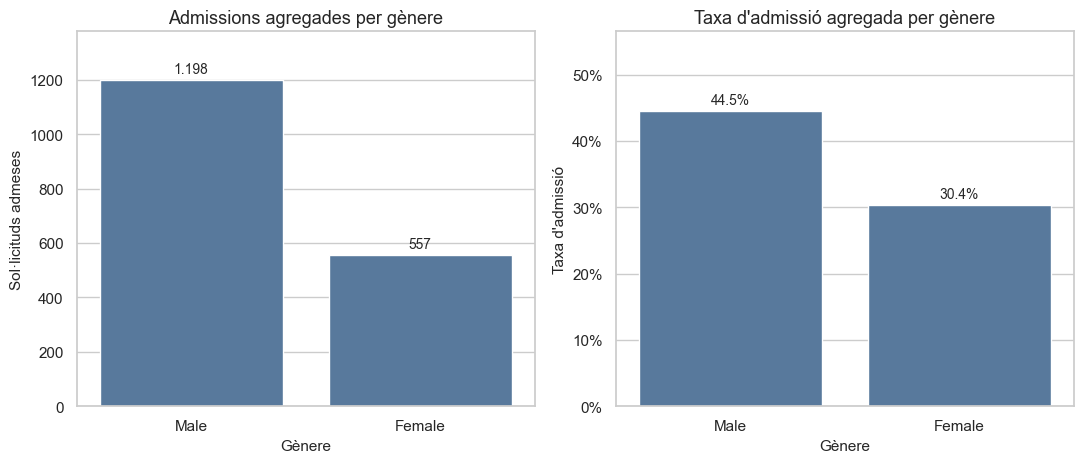

In [11]:
# Gràficament, mostrem el recompte absolut d'admissions i la taxa corresponent.
plot_data = marginal_summary.reset_index().rename(columns={"Taxa d'admissió": "admission_rate"})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
count_ax, rate_ax = axes

sns.barplot(data=plot_data, x="Gender", y="Admitted", order=GENDER_ORDER, ax=count_ax, color="#4C78A8")
count_ax.set_title("Admissions agregades per gènere")
count_ax.set_xlabel("Gènere")
count_ax.set_ylabel("Sol·licituds admeses")
count_ax.set_ylim(0, max(plot_data["Admitted"]) * 1.15)
label_count_bars(count_ax, fontsize=10)

sns.barplot(data=plot_data, x="Gender", y="admission_rate", order=GENDER_ORDER, ax=rate_ax, color="#4C78A8")
rate_ax.set_title("Taxa d'admissió agregada per gènere")
rate_ax.set_xlabel("Gènere")
rate_ax.set_ylabel("Taxa d'admissió")
rate_ax.yaxis.set_major_formatter(PercentFormatter(1.0))
rate_ax.set_ylim(0, max(plot_data["admission_rate"]) + 0.12)
label_percent_bars(rate_ax, fontsize=10)
plt.tight_layout()
plt.show()


En l'agregat, la taxa d'admissió masculina és superior a la femenina. Aquesta és una afirmació purament observacional, és a dir, del primer esglaó en la jerarquia causal de [Pearl (2009)](#pearl2009causality) (cf. Memòria): $P(Y=1\mid G=g)$ (probabilitat d'admissió coneixent el gènere). Aquesta, però, encara no diu què ha generat aquesta diferència. Com ja hem comentat, el paper original subratlla precisament que aquesta lectura agregada s'ha d'agafar amb pinces ([Bickel, Hammel i O'Connell, 1975](#bickel1975sex)).


## 4. Preparació estratificada per departament

Ara condicionem pel departament. Aquesta estratificació és central, ja que l'admissió és heterogènia entre departaments. [Bickel, Hammel i O'Connell (1975)](#bickel1975sex), de fet, argumenten que el resultat d'una sol·licitud depèn principalment del departament al qual s'aplica, i que per això cal prendre cada departament com una unitat separada. És cada departament qui té la seva pròpia demanda i el seu propi criteri d'admissió (el que anomenarem selectivitat o _selectivity_).

En aquesta secció, però, encara no volem explicar la paradoxa. Només preparem les taules estratificades que necessitarem després: primer per als contrastos estadístics i, més endavant, per entendre com la distribució de sol·licituds entre departaments acaba afectant les taxes d'admissió agregades.

In [12]:
# Agrupem per Dept, Gender i Admit.
# La sortida encara conté una fila per parella Dept-Gender, amb dues columnes d'admissió.
dept_gender_counts = (
    df.groupby(["Dept", "Gender", "Admit"], observed=True)["Freq"]
    .sum()
    .unstack("Admit")
    .reindex(columns=ADMIT_ORDER)
    .reset_index()
)

# Total de sol·licituds per Dept-Gender i taxa d'admissió corresponent.
dept_gender_counts["Total"] = dept_gender_counts["Admitted"] + dept_gender_counts["Rejected"]
dept_gender_counts["Taxa d'admissió"] = dept_gender_counts["Admitted"] / dept_gender_counts["Total"]

# Taula Gender x Admit separada per a cada departament.
# La reutilitzarem en els contrastos, el CMH i les mesures d'associació.
dept_tables = {dept: gender_admit_table(df.loc[df["Dept"] == dept]) for dept in DEPT_ORDER}

In [13]:
# Mostrem, per cada departament i gènere:
# - el recompte d'admissions, 
# - de rebuigs,
# - el total de sol·licituds.
dept_gender = pd.concat(
    {
        gender: (
            dept_gender_counts.loc[dept_gender_counts["Gender"] == gender]
            .set_index("Dept")[["Admitted", "Rejected", "Total"]]
            .reindex(DEPT_ORDER)
            .astype(int)
        )
        for gender in GENDER_ORDER
    },
    axis=1,
)
display(dept_gender)

Male                  Female               
Admit Admitted Rejected Total Admitted Rejected Total
Dept                                                 
A          512      313   825       89       19   108
B          353      207   560       17        8    25
C          120      205   325      202      391   593
D          138      279   417      131      244   375
E           53      138   191       94      299   393
F           22      351   373       24      317   341

In [14]:
# Ens quedem amb la selectivitat per gènere i departament, obviant els rebuigs.
# Ho mostrem en termes de percentatges.
rate_table = dept_gender_counts.pivot(index="Dept", columns="Gender", values="Taxa d'admissió").reindex(
    index=DEPT_ORDER, columns=GENDER_ORDER
)
percent_table(rate_table)

Gender,Male,Female
Dept,,
A,62.1%,82.4%
B,63.0%,68.0%
C,36.9%,34.1%
D,33.1%,34.9%
E,27.7%,23.9%
F,5.9%,7.0%


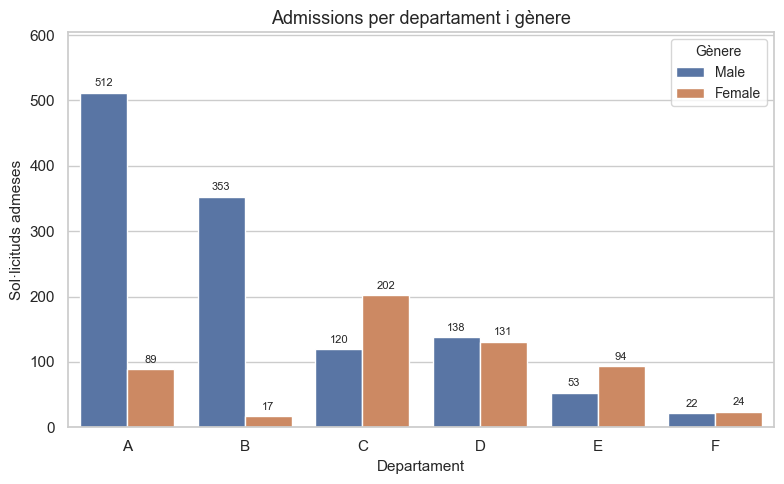

In [15]:
# Gràficament, de moment ens quedem amb els recomptes absoluts d'admissions.
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=dept_gender_counts,
    x="Dept",
    y="Admitted",
    hue="Gender",
    order=DEPT_ORDER,
    hue_order=GENDER_ORDER,
    ax=ax,
)
ax.set_title("Admissions per departament i gènere")
ax.set_xlabel("Departament")
ax.set_ylabel("Sol·licituds admeses")
ax.set_ylim(0, max(dept_gender_counts["Admitted"]) * 1.18)
label_count_bars(ax)
ax.legend(title="Gènere", loc="upper right")
plt.tight_layout()
plt.show()


Les taules anteriors mostren els recomptes absoluts i les taxes d'admissió corresponents. A la figura, de moment, només conservem els recomptes d'admissions per departament i gènere. Deixarem per més endavant la comparació visual de les taxes d'admissió i la discussió sobre el gènere i la selectivitat d'un departament.

Per ara, el paper d'aquesta secció és deixar les taules a punt per explicar la paradoxa de Simpson més endavant, juntament amb la selectivitat dels departaments. Per tant, tornem a la inferència estadística per reforçar encara més aquesta associació entre les dues variables (gènere i admissió).

## 5. Contrast estadístic d'associació

### Estadístic de Pearson i test de la $\chi$-quadrat

Un cop hem vist la taula marginal i les taules estratificades, ens podem fer la següent pregunta: **respecte de les dades observades, podria haver-hi independència estadística entre gènere i admissió?** Per a la taula agregada, el contrast és:

$$
H_0: G \perp\!\!\!\perp Y, \qquad H_1: G \not\perp\!\!\!\perp Y.
$$

Si tenim $n$ realitzacions d'un experiment amb $m$ resultats possibles i resumim la mostra amb el vector de freqüències absolutes (cf. [Vilar, 2024](#vilar2024estadistica)):

$$
f=(n_1,\ldots,n_m), \qquad n_1+\cdots+n_m=n,
$$

el contrast khi-quadrat d'ajustament parteix d'una hipòtesi nul·la de la forma

$$
H_0:p_j=p_j^0,\quad j=1,\ldots,m.
$$

L'estadístic de Pearson és (cf. [Vilar, 2024](#vilar2024estadistica))

$$
D_n\equiv D_n(x)=\sum_{j=1}^m \frac{(n_j-np_j^0)^2}{np_j^0}
=\sum_{j=1}^m \frac{n\left(\frac{n_j}{n}-p_j^0\right)^2}{p_j^0}.
$$

Sota $H_0$, i amb les condicions asimptòtiques habituals, tenim:

$$
D_n \xrightarrow[n\to\infty]{\mathcal{L}} \chi^2_{m-1}.
$$

En una taula de contingència, cada cel·la correspon a una categoria. Si la taula té files $i=1,\ldots,r$, columnes $j=1,\ldots,c$, recomptes observats $O_{ij}$ i total $n$, sota independència les freqüències esperades es calculen amb els marges:

$$
E_{ij}=\frac{O_{i\cdot}O_{\cdot j}}{n}.
$$

Així, l'estadístic pot quedar escrit com:

$$
X^2=\sum_{i=1}^r\sum_{j=1}^c \frac{(O_{ij}-E_{ij})^2}{E_{ij}}.
$$

Com que les probabilitats esperades sota independència s'estimen amb les marginals, els graus de llibertat són $(r-1)(c-1)$. En les nostres taules $\text{Gender}\times\text{Admit}$, tenim $r=c=2$ i, per tant, hi ha un sol grau de llibertat.

L'objectiu d'aquesta secció és deliberadament modest: demostrar (un altre cop) que hi ha associació entre el gènere i l'admissió. Un $p$-valor petit (més petit que una certa tolerància $\alpha$) indica que hauríem de rebutjar $H_0$. Recordem que, tot i l'evident correlació estadística entre aquestes dues variables, no podem identificar cap efecte causal ni resoldre la pregunta sobre discriminació. **Correlació no implica causalitat**.

En particular, aplicarem aquest contrast dues vegades. Primer, a la taula agregada $\text{Gender}\times\text{Admit}$. Després, a cada departament per separat. En tots els casos fem servir el mateix criteri: fixem $\alpha=0.05$ només com a llindar, de manera que rebutgem $H_0$ quan el $p$-valor és inferior a $\alpha$.

També mostrarem la freqüència observada mínima i la freqüència esperada mínima. Aquestes dues columnes són un indicador de si l'aproximació khi-quadrat és vàlida o no. La regla pràctica habitual ([Vilar, 2024, obs. 4.3.3](#vilar2024estadistica)) és que l'aproximació asimptòtica és raonable quan $n_j\geq 5$ i $np_j^0\geq 5$; en una taula de contingència això correspon a comprovar que $O_{ij}\geq 5$ i $E_{ij}\geq 5$.


In [16]:
ALPHA = 0.05

In [17]:
def format_pvalue(pvalue: float) -> str:
    """Formata un p-valor per presentar-lo en una taula.

    Parameters
    ----------
    pvalue:
        p-valor retornat per un contrast estadístic.

    Returns
    -------
    str
        p-valor amb quatre decimals si no és extremadament petit, o en notació
        científica si és inferior a `0.001`.
    """
    return f"{pvalue:.2e}" if pvalue < 0.001 else f"{pvalue:.4f}"


def chi_square_independence(contingency: pd.DataFrame, label: str, alpha: float = ALPHA) -> pd.Series:
    """Aplica el contrast khi-quadrat de Pearson a una taula de contingència.

    Parameters
    ----------
    contingency:
        Taula de contingència amb recomptes observats. En aquest notebook serà
        sempre una taula `Gender x Admit`, però la funció és vàlida per a una
        taula bidimensional general.
    label:
        Nom de la taula analitzada. Serveix per identificar la fila de sortida.
    alpha:
        Nivell de significació.

    Returns
    -------
    pandas.Series
        Sèrie amb l'estadístic khi-quadrat, els graus de llibertat, el p-valor,
        les freqüències observada i esperada mínimes i una decisió al nivell `alpha`.

    Notes
    -----
    Usem `correction=False` per obtenir el contrast khi-quadrat de Pearson sense
    correcció de continuïtat. Les freqüències del dataset són prou grans per no
    dependre d'una correcció pensada per taules `2 x 2` amb mostres petites.
    """
    # SciPy calcula el contrast complet a partir de la taula observada.
    # Consultant la seva documentació, veiem que retorna quatre objectes:
    #   chi2_stat: valor que pren l'estadístic de la khi-quadrat
    #   pvalue: probabilitat de veure una discrepància com a mínim tan extrema sota H0
    #   dof: graus de llibertat de la taula
    #   expected: taula E_ij de freqüències esperades sota H0
    chi2_stat, pvalue, dof, expected = chi2_contingency(contingency, correction=False)

    # La condició pràctica dels apunts demana mirar dues coses, com ja hem dit.
    # Guardem els mínims de totes dues matrius per verificar-ho.
    min_observed = contingency.to_numpy(dtype=float).min()
    min_expected = expected.min()

    # Decidim si rebutjar o no H0 al nivell alpha en funció del p-valor.
    decision = "Sí" if pvalue < alpha else "No"

    return pd.Series(
        {
            "taula": label,
            "chi2": chi2_stat,
            "gl": int(dof),
            "p_val": pvalue,
            "freq_observada_min": min_observed,
            "freq_esperada_min": min_expected,
            "rebutjar_H0": decision,
        }
    )


def expected_cell(contingency: pd.DataFrame, label: str) -> pd.DataFrame:
    """Compara freqüències observades i esperades per a cada cel·la d'una taula.

    Parameters
    ----------
    contingency:
        Taula `Gender x Admit` amb freqüències observades.
    label:
        Etiqueta de la taula, per exemple `Agregada` o `Departament A`.

    Returns
    -------
    pandas.DataFrame
        Per a cada cel·la, tenim la freqüència observada, la freqüència
        esperada sota independència i la contribució de la cel·la a l'estadístic
        khi-quadrat.
    """
    # Tornem a cridar `chi2_contingency` perquè volem les freqüències esperades E_ij.
    # Els altres tres retorns ja els hem calculat abans. 
    chi2_stat, _, _, expected = chi2_contingency(contingency, correction=False)

    # Convertim la taula observada O_ij a array, necessitem anar cel·la a cel·la.
    observed = contingency.to_numpy(dtype=float)

    # Cada cel·la serà una contribució_{ij} = (O_ij - E_ij)^2 / E_ij al valor total de X^2.
    contribution = (observed - expected) ** 2 / expected

    # NOTA: Si sumem tota aquesta matriu, recuperem `chi2_stat`.
    assert np.isclose(contribution.sum(), chi2_stat)

    rows = []
    for row_idx, gender in enumerate(contingency.index):
        for col_idx, admit in enumerate(contingency.columns):
            rows.append(
                {
                    "taula": label,
                    "Gender": gender,
                    "Admit": admit,
                    "observat": observed[row_idx, col_idx],
                    "esperat_H0": expected[row_idx, col_idx],
                    "contribucio_chi2": contribution[row_idx, col_idx],
                }
            )
    return pd.DataFrame(rows)


In [18]:
# Taula agregada Gender x Admit.
chi_square_rows = [chi_square_independence(marginal_counts, "Agregada")]

# Repetim el mateix contrast, ara estratificant per departament.
for dept, dept_table in dept_tables.items():
    chi_square_rows.append(chi_square_independence(dept_table, f"Departament {dept}"))

chi_square = pd.DataFrame(chi_square_rows).set_index("taula")

# Presentem els resultats
chi_square_display = chi_square.copy()
chi_square_display["chi2"] = chi_square_display["chi2"].map(lambda x: f"{x:.3f}")
chi_square_display["p_val"] = chi_square_display["p_val"].map(format_pvalue)
chi_square_display["freq_observada_min"] = chi_square_display["freq_observada_min"].map(lambda x: f"{x:.1f}")
chi_square_display["freq_esperada_min"] = chi_square_display["freq_esperada_min"].map(lambda x: f"{x:.1f}")
chi_square_display


,chi2,gl,p_val,freq_observada_min,freq_esperada_min,rebutjar_H0
taula,,,,,,
Agregada,92.205,1,7.81e-22,557.0,711.5,Sí
Departament A,17.248,1,3.28e-05,19.0,38.4,Sí
Departament B,0.254,1,0.6145,8.0,9.2,No
Departament C,0.754,1,0.3854,120.0,114.0,No
Departament D,0.298,1,0.5852,131.0,127.4,No
Departament E,1.001,1,0.3171,53.0,48.1,No
Departament F,0.384,1,0.5354,22.0,22.0,No


La taula anterior resumeix els contrasts que acabem de fer. La columna `rebutjar_H0`, amb llindar $\alpha=0.05$, indica directament si rebutgem la hipòtesi nul·la d'independència. D'aquesta manera, només la taula agregada i el departament A porten a rebutjar $H_0$.

Per això, a continuació no descompondrem totes les taules, simplement comentem tres casos que expliquen el patró de la taula anterior:

- `Agregada`: és el contrast marginal i rebutgem $H_0$ perquè el $p$-valor és ínfim.
- `Departament A`: és l'únic departament on el contrast també rebutja $H_0$.
- `Departament F`: és un contrapunt clar (hi ha d'altres, com D), perquè no rebutgem $H_0$ i té freqüències observades molt properes a les esperades.

Aquest és només un petit incís que ens serveixi per entendre com les discrepàncies entre freqüències observades i esperades fan créixer l'estadístic $X^2$.


In [19]:
# Agafem la taula agregada i els dos departaments
tables_for_diagnostics = {
    "Agregada": marginal_counts,
    "Departament A": dept_tables["A"],
    "Departament F": dept_tables["F"],
}

# Per a cada taula, calculem O_ij, E_ij i la contribució (O_ij-E_ij)^2/E_ij.
# Això explica quines cel·les fan créixer l'estadístic X^2
cell_diagnostics = pd.concat(
    [expected_cell(table, label) for label, table in tables_for_diagnostics.items()],
    ignore_index=True,
)

# Presentem la taula
cell_diagnostics_display = cell_diagnostics.copy()
cell_diagnostics_display["observat"] = cell_diagnostics_display["observat"].astype(int)
for col in ["esperat_H0", "contribucio_chi2"]:
    cell_diagnostics_display[col] = cell_diagnostics_display[col].map(lambda x: f"{x:.2f}")
cell_diagnostics_display

,taula,Gender,Admit,observat,esperat_H0,contribucio_chi2
0,Agregada,Male,Admitted,1198,1043.46,22.89
1,Agregada,Male,Rejected,1493,1647.54,14.50
2,Agregada,Female,Admitted,557,711.54,33.56
3,Agregada,Female,Rejected,1278,1123.46,21.26
4,Departament A,Male,Admitted,512,531.43,0.71
5,Departament A,Male,Rejected,313,293.57,1.29
6,Departament A,Female,Admitted,89,69.57,5.43
7,Departament A,Female,Rejected,19,38.43,9.82
8,Departament F,Male,Admitted,22,24.03,0.17
9,Departament F,Male,Rejected,351,348.97,0.01


La taula agregada rebutja clarament la hipòtesi nul·la: obtenim $X^2\approx 92.205$ i un $p$-valor aproximadament igual a $7.81\cdot 10^{-22}$ (veure el `chi_square_display`, més amunt). Ara bé, això és així perquè les freqüències observades s'allunyen molt de les esperades sota independència. Per exemple, en les agregades: sota $H_0$ esperaríem uns `1043` homes admesos, però n'observem `1198`; i esperaríem aproximadament `711` dones admeses, però n'observem `557`.

La situació canvia radicalment quan estratifiquem. Això posa en relleu per què els $p$-valors estratificats per departament poden ser tan diferents, per exemple, al comparar entre els departaments A i F. 

- Al departament A, sota independència esperaríem aproximadament `69` dones admeses i `38` dones rebutjades, però observem `89` dones admeses i només `19` dones rebutjades. La desviació és gran en relació amb el que s'esperaria sota $H_0$, i per això el $p$-value és de `3.28e-05`.

- En canvi, al departament F les freqüències observades i esperades són molt properes: homes admesos `22` contra `24` esperats, i dones admeses `24` contra `22` esperades. Per això el $p$-value és molt més gran, aproximadament `0.535`, i no podem rebutjar la hipòtesi nul·la amb $\alpha=0.05$ dins d'aquest departament.

Les columnes `freq_observada_min` i `freq_esperada_min` serveixen per justificar el que hem dit abans: en totes les taules tenim $O_{ij},E_{ij}\geq 5$ (i.e. l'aproximació asimptòtica khi-quadrat és raonable). Si més no, i en la línia del que ja hem fet, rebutjar independència marginal no equival a provar en cap cas una discriminació (de la mateixa manera que no rebutjar-la dins d'un departament tampoc prova absència de discriminació). 


### Cochran-Mantel-Haenszel (CMH)

El test de Cochran-Mantel-Haenszel ([Mantel i Haenszel, 1959](#mantel1959)) ens serveix per fer un pas intermedi entre les dues lectures anteriors. Aquest test no mira només la taula agregada, però tampoc es queda en sis tests separats. La pregunta és: si separem per departament, queda una associació comuna entre gènere i admissió? Aquí "controlar" per departament vol dir condicionar o estratificar, no fer cap afirmació causal sobre què passaria si fixéssim el departament (encara no hem parlat d'_intervencions_). Si per al departament $k$ escrivim la taula com:

$$
\begin{array}{c|cc|c}
 & Y=1 & Y=0 & \text{total} \\
\hline
G=\text{Male} & a_k & b_k & a_k+b_k \\
G=\text{Female} & c_k & d_k & c_k+d_k \\
\hline
\text{total} & a_k+c_k & b_k+d_k & n_k
\end{array}
$$

aleshores, sota la hipòtesi nul·la d'independència entre `Gender` i `Admit` dins de cada estrat, l'esperança i la variància d'$a_k$ són:

$$
\mathbb{E}_0(a_k)=\frac{(a_k+b_k)(a_k+c_k)}{n_k}\quad\text{i}\quad\operatorname{Var}_0(a_k)=\frac{(a_k+b_k)(c_k+d_k)(a_k+c_k)(b_k+d_k)}{n_k^2(n_k-1)}.
$$

L'estadístic de Cochran-Mantel-Haenszel és:

$$
M^2=\frac{\left[\sum_k \left(a_k-\mathbb{E}_0(a_k)\right)\right]^2}{\sum_k \operatorname{Var}_0(a_k)}.
$$

Sota la hipòtesi nul·la, aquest estadístic segueix asimptòticament una distribució $\chi^2$ amb $1$ grau de llibertat. En termes d'\textit{odds ratio}, això equival a contrastar si l'associació estratificada és compatible amb una odds ratio comuna igual a $1$. Ara bé, això no vol dir que les odds ratio observades a tots els departaments hagin de ser exactament iguals; aquesta és una altra pregunta, i la mirarem tot seguit amb el test de [Breslow-Day](#breslow1980).


In [20]:
stratified_tables = []

for dept in DEPT_ORDER:
    dept_table = dept_tables[dept]
    stratified_tables.append(dept_table.to_numpy(dtype=float))
    print(f"Departament {dept}")
    display(dept_table)

Departament A


Admit,Admitted,Rejected
Gender,,
Male,512,313
Female,89,19


Departament B


Admit,Admitted,Rejected
Gender,,
Male,353,207
Female,17,8


Departament C


...

Admit,Admitted,Rejected
Gender,,
Male,138,279
Female,131,244


Departament E


Admit,Admitted,Rejected
Gender,,
Male,53,138
Female,94,299


Departament F


Admit,Admitted,Rejected
Gender,,
Male,22,351
Female,24,317


No farem tots aquests càlculs manualment, perquè `statsmodels` ja té la classe [`StratifiedTable`](#statsmodels-stratifiedtable) per treballar amb taules $2\times 2$. Aprofitarem una mica més el paquet: no només extraurem el p-valor del test, sinó també l'OR agrupada de [Mantel-Haenszel](#mantel1959) i el seu interval de confiança.

In [21]:
stratified_test = StratifiedTable(stratified_tables)
stratified_test.summary()

,Estimate,LCB,UCB
Pooled odds,0.905,0.772,1.060
Pooled log odds,-0.100,-0.259,0.059
Pooled risk ratio,0.945,,
,,,
,Statistic,P-value,
Test of OR=1,1.525,0.217,
Test constant OR,18.826,0.002,
,,,
Number of tables,6,,
Min n,584,,


Ara bé, convé no agafar-ho tot: només ens interessen els tests de [Mantel-Haenszel](#mantel1959) i de [Breslow-Day](#breslow1980): el _Cochran's Q_ és per dades binàries aparellades o mesures repetides sobre les mateixes unitats sota diverses condicions. Aquí tenim taules $2\times 2$ estratificades per departament, però no els mateixos individus observats repetidament en diversos departaments. Les hipòtesis nul·les $H_0$ seran les següents:
- _Mantel-Haenszel_: OR comuna = 1.
- _Breslow-Day-Tarone_: ORs iguals entre departaments.

In [22]:
# Mantel-Haenszel: contrastem si l'OR comuna estratificada és igual a 1.
cmh_test = stratified_test.test_null_odds()
or_mh_lcb, or_mh_ucb = stratified_test.oddsratio_pooled_confint()

# Breslow-Day amb ajust de Tarone: contrastem si les OR dels estrats són homogènies.
equal_odds_test = stratified_test.test_equal_odds(adjust=True)

cmh = pd.DataFrame(
    [
        {
            "contrast": "Mantel-Haenszel",
            "gl": 1,
            "statistic": float(cmh_test.statistic),
            "p_value": float(cmh_test.pvalue)
        },
        {
            "contrast": "Breslow-Day-Tarone",
            "gl": len(stratified_tables) - 1,
            "statistic": float(equal_odds_test.statistic),
            "p_value": float(equal_odds_test.pvalue)
        },
    ]
).set_index("contrast")

cmh_display = cmh.copy()
cmh_display["statistic"] = cmh_display["statistic"].map(lambda x: f"{x:.3f}")
cmh_display["p_value"] = cmh_display["p_value"].map(format_pvalue)

display(cmh_display)

,gl,statistic,p_value
contrast,,,
Mantel-Haenszel,1,1.525,0.2169
Breslow-Day-Tarone,5,18.826,0.0021


In [23]:
print(f"OR_MH: {float(stratified_test.oddsratio_pooled)}")
print(f"INTERVAL CONFIANÇA: [{or_mh_lcb:.3f}, {or_mh_ucb:.3f}]")

OR_MH: 0.9046968282586231
INTERVAL CONFIANÇA: [0.772, 1.060]


**Un altre cop, la lectura estratificada no diu el mateix que la taula marginal**. Si resumim els sis departaments amb una OR comuna de Mantel-Haenszel, obtenim $\widehat{OR}_{MH}\approx 0.905$, amb un interval de confiança aproximat $[0.772,1.060]$. Com que el p-valor del test CMH és aproximadament $0.217$, no rebutgem la hipòtesi que aquesta OR comuna sigui igual a $1$.

Ara bé, això no vol dir que els departaments siguin tots iguals. El test de Breslow-Day-Tarone dona un p-valor al voltant de $0.002$, de manera que sí que posa en dubte la idea d'una OR perfectament homogènia entre departaments. L'OR de Mantel-Haenszel és un resum útil, però força esquemàtic.

Per tant, el CMH ens ajuda a ordenar la comparació condicionada per departament, però segueix sense tancar cap discussió causal ni cap judici sobre discriminació. Ens diu una cosa més modesta: quan estratifiquem, l'evidència d'una associació comuna forta desapareix, però resumir-ho tot amb una sola OR també és una simplificació. Justament per això, a la secció següent mirarem les mesures d'associació departament per departament.

## 6. Mesures d'associació en taules de contingència

Seguim avançant en la direcció proposada per [Simpson (1951)](#simpson1951) i la notació de [Good i Mittal (1987)](#good1987) i [Samuels (1993)](#samuels1993). La secció anterior ens ha donat una OR comuna, però també ens ha avisat que els departaments no es comporten tots igual. Per això ara tornem a les mesures descriptives de cada taula $\text{Gender}\times\text{Admit}$:

- la diferència de taxes d'admissió, $P(Y=1\mid G=\text{Male})-P(Y=1\mid G=\text{Female})$;
- l'odds ratio (OR), que val $1$ quan no hi ha associació en una taula $2\times 2$;
- el signe de l'associació, $\alpha(D_i)$.

[Simpson (1951)](#simpson1951) és el primer que mostra que les taules de contingència poden ser delicades; [Good i Mittal (1987)](#good1987) formulen explícitament l'amalgamació de taules $2\times 2$; i [Samuels (1993)](#samuels1993) situa la paradoxa de Simpson dins d'una família més general de fenòmens de reversió d'associació.

Seguint aquesta notació, per cada estrat $D_i$ (departament) escrivim la taula, en aquest ordre, com $D_i=(a_i,b_i,c_i,d_i)$, on $a_i$ són homes admesos, $b_i$ homes rebutjats, $c_i$ dones admeses i $d_i$ dones rebutjades. La taula agregada és $D=\sum_i D_i$, és a dir, la suma cel·la a cel·la de les taules de cada departament (anomenarem aquesta taula _amalgamació_). Definim:

$$
\alpha(D_i)=a_i d_i-b_i c_i.
$$

A partir d'aquest valor, el signe de l'associació, per a aquesta orientació de files, queda així:

$$
\alpha(D_i)
\begin{cases}
>0 &\Longleftrightarrow a_i d_i>b_i c_i,\\
=0 &\Longleftrightarrow a_i d_i=b_i c_i,\\
<0 &\Longleftrightarrow a_i d_i<b_i c_i.
\end{cases}
$$

En el nostre cas, $\alpha>0$ vol dir que la taula afavoreix $\text{Male}$; $\alpha<0$ vol dir que afavoreix $\text{Female}$. El valor absolut de $ad-bc$ no és una bona mesura directa d'intensitat quan les taules tenen mides molt diferents; aquí el farem servir sobretot pel signe, i deixarem l'escala de l'associació a l'OR i al log-OR.


In [24]:
def association_measures(counts: pd.DataFrame) -> pd.Series:
    """Calcula mesures descriptives d'associació per a `Gender x Admit`.

    Parameters
    ----------
    counts:
        DataFrame amb files `Male` i `Female`, columnes `Admitted` i `Rejected`,
        i valors iguals als recomptes de cada cel·la.

    Returns
    -------
    pandas.Series
        Sèrie amb mesures de taula `2 x 2`:
        - taxa d'admissió masculina;
        - taxa d'admissió femenina;
        - diferència de taxes `Male - Female`;
        - producte creuat `ad-bc`;
        - signe de `alpha`;
        - odds ratio `Male vs Female`;
        - logaritme de l'odds ratio.

    Notes
    -----
    Només volem calcular mesures de taula de contingència.
    Amb la notació de Good i Mittal, fem servir:

        a = Male admitted,    b = Male rejected,
        c = Female admitted,  d = Female rejected.

    Llavors `ad-bc` determina el signe de l'associació. És positiu quan la
    taxa d'admissió masculina és superior a la femenina, zero quan no hi ha
    associació segons aquesta mesura, i negatiu quan afavoreix `Female`.
    """
    # Reindexem per garantir coherència
    # I convertim a float per evitar problemes de tipus.
    counts = counts.reindex(index=GENDER_ORDER, columns=ADMIT_ORDER).astype(float)

    # Extracció explícita de les quatre cel·les de la taula 2 x 2.
    male_adm, male_rej = counts.loc["Male", "Admitted"], counts.loc["Male", "Rejected"]
    female_adm, female_rej = counts.loc["Female", "Admitted"], counts.loc["Female", "Rejected"]

    # Taxes d'admissió per fila: admès / total de sol·licituds del gènere.
    total_male, total_female = male_adm + male_rej, female_adm + female_rej
    male_rate = male_adm / total_male
    female_rate = female_adm / total_female

    # alpha(D_i) = ad - bc.
    ad_bc = male_adm * female_rej - male_rej * female_adm

    # Odds ratio de la taula 2 x 2. Table2x2 també ens dona el log-OR.
    table_2x2 = Table2x2(counts.to_numpy(dtype=float))

    return pd.Series(
        {
            "Taxa male": male_rate,
            "Taxa female": female_rate,
            "TM-TF": male_rate - female_rate,
            "ad-bc": ad_bc,
            "OR": table_2x2.oddsratio,
            "log_OR": table_2x2.log_oddsratio,
        }
    )

# Convertim la Series a Dataframe i posem un nom a la fila.
marginal_measures = association_measures(marginal_counts).to_frame("Agregat").T

# Presentem la taula
marginal_measures_display = marginal_measures.copy()
for col in ["Taxa male", "Taxa female", "TM-TF"]:
    marginal_measures_display[col] = marginal_measures_display[col].map(pct)
marginal_measures_display["ad-bc"] = marginal_measures_display["ad-bc"].map(lambda x: f"{x:.0f}")
marginal_measures_display


,Taxa male,Taxa female,TM-TF,ad-bc,OR,log_OR
Agregat,44.5%,30.4%,14.2%,699443,1.8411,0.6104


In [25]:
# Apliquem la mateixa funció de mesures a cada departament.
dept_measures = pd.DataFrame(
    {dept: association_measures(table) for dept, table in dept_tables.items()}
).T

# Versió de presentació amb percentatges a les columnes que són proporcions.
dept_measures_display = dept_measures.copy()
for col in ["Taxa male", "Taxa female", "TM-TF"]:
    dept_measures_display[col] = dept_measures_display[col].map(pct)
dept_measures_display["ad-bc"] = dept_measures_display["ad-bc"].map(lambda x: f"{x:.0f}")
dept_measures_display


,Taxa male,Taxa female,TM-TF,ad-bc,OR,log_OR
A,62.1%,82.4%,-20.3%,-18129,0.3492,-1.0521
B,63.0%,68.0%,-5.0%,-695,0.8025,-0.2200
C,36.9%,34.1%,2.9%,5510,1.1331,0.1249
D,33.1%,34.9%,-1.8%,-2877,0.9213,-0.0820
E,27.7%,23.9%,3.8%,2875,1.2216,0.2002
F,5.9%,7.0%,-1.1%,-1450,0.8279,-0.1889


La taula agregada té $\alpha>0$: segons $ad-bc$, l'associació marginal afavoreix $\text{Male}$. Això també es veu en l'OR agregada, que és aproximadament $1.84$. En canvi, als departaments $A$, $B$, $D$ i $F$ el signe és negatiu, mentre que a $C$ i $E$ continua sent positiu. El departament $A$ és el cas que més pesa visualment en aquesta lectura: té una diferència de taxes gran i una OR clarament per sota d'$1$.

Per això no podem parlar d'una reversió de Simpson en sentit estricte, perquè no tots els estrats apunten en sentit contrari. Una conclusió més correcta, i més conservadora, és que quan agrupem tots els departaments en una única taula, la comparació global pot canviar respecte de les comparacions fetes departament per departament. Una pregunta natural que ens podem fer és d'on surt aquest canvi, i aquí ja entren els pesos de cada departament dins de cada grup.

## 7. La paradoxa de Simpson

Ara recuperem la lectura estratificada que abans havíem deixat preparada. Estratificant; és a dir, dins dels departaments, la imatge ja no coincideix amb la lectura marginal. En alguns departaments la taxa femenina és superior, en altres és inferior. De fet, en el departament més exigent ($F$), la taxa més alta és la femenina. En el cas `UCBAdmissions` concret no tots els estrats canvien de signe respecte de l'agregat, de manera que no tenim una reversió perfecta en tots els departaments. Però sí que tenim el fenomen que ens interessa: **una associació marginal, en la taula global, pot canviar quan es condiciona per una variable rellevant**. En el llenguatge de [Samuels (1993)](#samuels1993), això ens situa en la família dels fenòmens de reversió d'associació.

La paradoxa apareix perquè es combinen dos fets ([Bickel, Hammel i O'Connell, 1975](#bickel1975sex)):

1. Homes i dones no sol·liciten els mateixos departaments en les mateixes proporcions.
2. Els departaments tenen taxes d'admissió molt diferents.

Les sol·licituds expliquen com es reparteixen homes i dones entre departaments; les admissions expliquen què passa dins d'aquests departaments.

L'estrat $D$ està relacionat tant amb la variable $G$ com amb la resposta $Y$ i és la versió pràctica de la condició d'_enllaç doble_ (cf. [Samuels, 1993](#samuels1993)) que fa possible la reversió d'associació. Matemàticament, podem expressar-ho com una aplicació de la llei de la probabilitat total condicionada a $G=g$:

$$
P(Y=1\mid G=g)=\sum_d P(Y=1\mid G=g,D=d)P(D=d\mid G=g).
$$

Per tant, la taxa marginal $P(Y=1\mid G=g)$ no depèn només de les taxes dins de cada departament, sinó també del pes que té cada departament dins del grup $G=g$. Això és exactament el pas de les taules estratificades $D_i$ a la _taula amalgamada_ (cf. [Samuels, 1993](#samuels1993)) $D=\sum_i D_i$.


In [26]:
# Distribució de sol·licituds per departament dins de cada gènere.
# Aquesta taula estima P(D=d | G=g) a partir de les freqüències observades.
applications_by_dept_gender = (
    df.groupby(["Gender", "Dept"], observed=True)["Freq"]
    .sum()
    .reset_index(name="Sol·licituds")
)

# Per a cada gènere, dividim les sol·licituds del departament pel total del gènere.
total_applications_by_gender = applications_by_dept_gender.groupby("Gender", observed=True)["Sol·licituds"].transform("sum")
applications_by_dept_gender["Proporció"] = applications_by_dept_gender["Sol·licituds"] / total_applications_by_gender

# Taula Dept x Gender amb pesos P(D=d | G=g).
applications_counts_table = (
    applications_by_dept_gender.pivot(index="Dept", columns="Gender", values="Sol·licituds")
    .reindex(index=DEPT_ORDER, columns=GENDER_ORDER)
    .astype(int)
)
display(applications_counts_table)

applications_table = applications_by_dept_gender.pivot(
    index="Dept", columns="Gender", values="Proporció"
).reindex(index=DEPT_ORDER, columns=GENDER_ORDER)

display(applications_table)
display(percent_table(applications_table))

Gender,Male,Female
Dept,,
A,825,108
B,560,25
C,325,593
D,417,375
E,191,393
F,373,341


Gender,Male,Female
Dept,,
A,0.3066,0.0589
B,0.2081,0.0136
C,0.1208,0.3232
D,0.1550,0.2044
E,0.0710,0.2142
F,0.1386,0.1858


Gender,Male,Female
Dept,,
A,30.7%,5.9%
B,20.8%,1.4%
C,12.1%,32.3%
D,15.5%,20.4%
E,7.1%,21.4%
F,13.9%,18.6%


La cel·la anterior mostra primer els recomptes absoluts de sol·licituds per departament i gènere, després les $P(D=d\mid G=g)$ i finalment la segona però en format percentual. Aquestes condicionades $P(D=d\mid G=g)$ ens indiquen dins de cada grup de gènere, quina proporció de sol·licituds va a cada departament. Les anomenarem habitualment _pesos_, ja que funcionen com a tal a la fórmula de probabilitats totals.

Aquests pesos no són semblants per a homes i dones. Per exemple, com ja havíem intuït més amunt, una part gran de les sol·licituds masculines es concentra als departaments $A$ i $B$, mentre que les sol·licituds femenines tenen més pes en departaments com $C$, $D$, $E$ i $F$. Aquesta és la primera peça de la paradoxa de Simpson: veure que $D$ està associat amb $G$. O, dit d'una altra manera, si coneixem el gènere de la sol·licitud tindrem més informació sobre el departament al qual s'ha presentat. El gràfic següent mostra visualment aquesta diferència de composició entre departaments. Encara no és tota l'explicació, perquè falta veure amb quines taxes d'admissió es combinen aquests pesos.


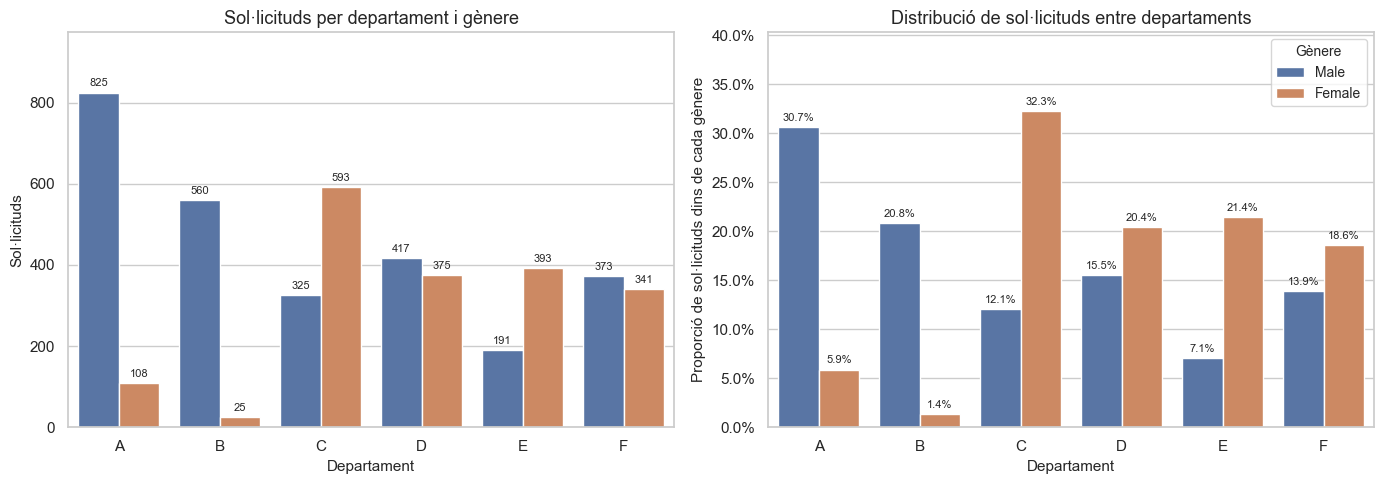

In [27]:
# Visualització dels pesos P(D=d | G=g), és a dir, sabent que una sol·licitud és de gènere g,
# quina és la probabilitat que aquesta vagi al departament d. A l'esquerra mostrem
# els recomptes absoluts de sol·licituds que generen aquestes proporcions.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
count_ax, proportion_ax = axes

sns.barplot(
    data=applications_by_dept_gender,
    x="Dept",
    y="Sol·licituds",
    hue="Gender",
    order=DEPT_ORDER,
    hue_order=GENDER_ORDER,
    ax=count_ax,
)
count_ax.set_title("Sol·licituds per departament i gènere")
count_ax.set_xlabel("Departament")
count_ax.set_ylabel("Sol·licituds")
count_ax.set_ylim(0, max(applications_by_dept_gender["Sol·licituds"]) * 1.18)
label_count_bars(count_ax)
if count_ax.get_legend() is not None:
    count_ax.get_legend().remove()

sns.barplot(
    data=applications_by_dept_gender,
    x="Dept",
    y="Proporció",
    hue="Gender",
    order=DEPT_ORDER,
    hue_order=GENDER_ORDER,
    ax=proportion_ax,
)
proportion_ax.set_title("Distribució de sol·licituds entre departaments")
proportion_ax.set_xlabel("Departament")
proportion_ax.set_ylabel("Proporció de sol·licituds dins de cada gènere")
proportion_ax.yaxis.set_major_formatter(PercentFormatter(1.0))
proportion_ax.set_ylim(0, max(applications_by_dept_gender["Proporció"]) + 0.08)
label_percent_bars(proportion_ax)
proportion_ax.legend(title="Gènere")
plt.tight_layout()
plt.show()


La taula següent resumirà la **selectivitat global** de cada departament, és a dir, la taxa d'admissió $P(Y=1\mid D=d)$ sense separar encara per gènere. Aquesta quantitat ens ve a confirmar fins a quin punt és difícil entrar a cada departament: $A$ i $B$ tenen taxes d'admissió altes, mentre que $E$ i sobretot $F$ són molt més restrictius.

Aquesta diferència és important perquè mostra que els departaments són compartiments estancs pel que fa al criteri de selecció (un no influencia l'altre). El fet que dos grups no es reparteixin igual entre departaments (i que aquests departaments tenen nivells d'admissió tan diferents) pot influir bastant en la taxa agregada de cada grup.

In [28]:
# Selectivitat global per departament: P(Y=1 | D=d), sense separar per gènere.
# Aquesta taula mesura la dificultat relativa d'entrar a cada departament.
dept_selectivity = (
    df.groupby(["Dept", "Admit"], observed=True)["Freq"]
    .sum()
    .unstack("Admit")
    .reindex(index=DEPT_ORDER, columns=ADMIT_ORDER)
)
dept_selectivity["Total"] = dept_selectivity.sum(axis=1)
dept_selectivity["Taxa global d'admissió"] = dept_selectivity["Admitted"] / dept_selectivity["Total"]

# Versió de presentació amb taxa en percentatge.
selectivity_display = dept_selectivity[["Admitted", "Rejected", "Total", "Taxa global d'admissió"]].copy()
selectivity_display["Taxa global d'admissió"] = selectivity_display["Taxa global d'admissió"].map(pct)
selectivity_display


Admit,Admitted,Rejected,Total,Taxa global d'admissió
Dept,,,,
A,601,332,933,64.4%
B,370,215,585,63.2%
C,322,596,918,35.1%
D,269,523,792,34.0%
E,147,437,584,25.2%
F,46,668,714,6.4%


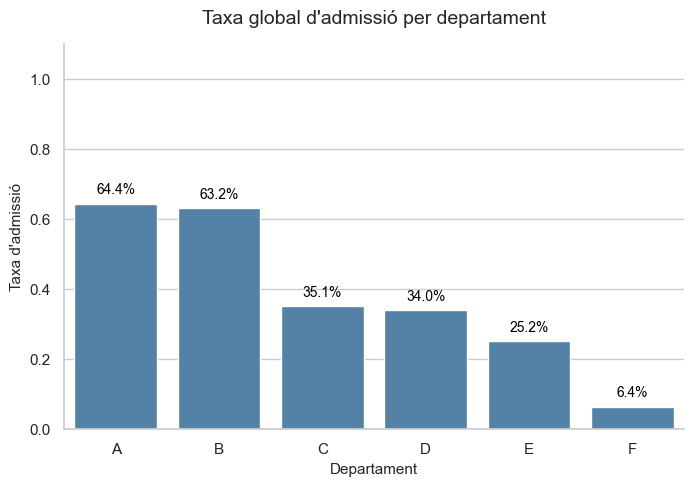

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

# Utilitzem reset_index() per passar 'Dept' (que és l'índex) a columna
sns.barplot(
    data=dept_selectivity.reset_index(),
    x="Dept",
    y="Taxa global d'admissió",
    color="steelblue",  # També pots provar palette="Blues_d"
    ax=ax
)

# Estètica i etiquetes
ax.set_title("Taxa global d'admissió per departament", fontsize=14, pad=15)
ax.set_ylabel("Taxa d'admissió")
ax.set_xlabel("Departament")
ax.set_ylim(0, 1.1)  # Donem una mica d'aire a la part superior per a les etiquetes

# Afegim el text del percentatge a sobre de cada barra
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', 
        fontsize=10, color='black', 
        xytext=(0, 5), textcoords='offset points'
    )

sns.despine() # Treu les línies superior i dreta de la caixa
plt.show()

En aquesta secció necessitem dues lectures alhora: la selectivitat global $P(Y=1\mid D=d)$ per veure que $D$ també està associat amb $Y$, i les taxes condicionades $P(Y=1\mid G=g,D=d)$ per entendre com es reconstrueixen les taxes marginals d'admissió. Així que, després de veure com es reparteixen les sol·licituds i la selectivitat global, recuperem la comparació visual de les taxes d'admissió per departament i gènere. No només volem saber on s'aplica, sinó també quina probabilitat d'admissió té cada grup dins de cada departament. 

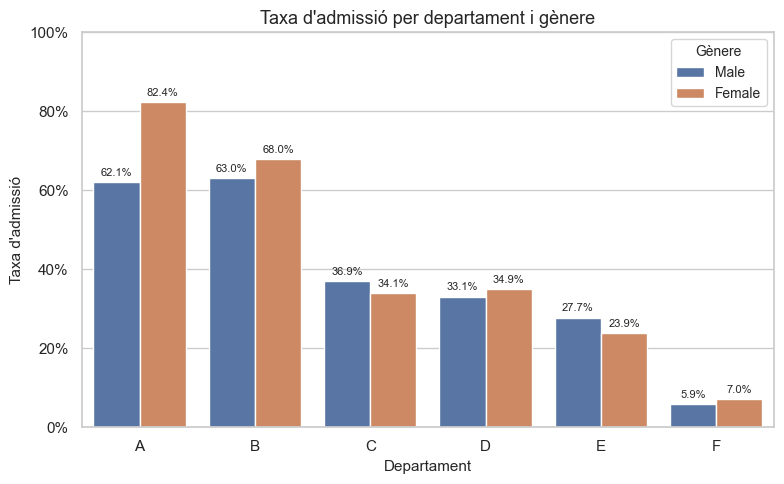

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=dept_gender_counts,
    x="Dept",
    y="Taxa d'admissió",
    hue="Gender",
    order=DEPT_ORDER,
    hue_order=GENDER_ORDER,
    ax=ax,
)
ax.set_title("Taxa d'admissió per departament i gènere")
ax.set_xlabel("Departament")
ax.set_ylabel("Taxa d'admissió")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.0)
label_percent_bars(ax)
ax.legend(title="Gènere", loc="upper right")
plt.tight_layout()
plt.show()


La gràfica anterior recupera la comparativa visual de taxes d’admissió per departament i gènere que havíem deixat entreveure més amunt. Aquesta és encara una lectura estratificada: mira $P(Y=1\mid G=g,D=d)$ i, per tant, compara homes i dones dins de cada departament.

Visualment, el que destaca és que les diferències entre departaments són molt més pronunciades que les diferències entre gèneres dins d’un mateix departament. Els departaments A i B tenen taxes d’admissió altes, mentre que E i sobretot F són molt més restrictius. Dins de cada departament, en canvi, les diferències entre homes i dones són en general moderades, amb l’excepció notable del departament A, on la taxa femenina és clarament superior.

Comencem a treure algunes conclusions importants. Fixem-nos que **els departaments més selectius (del C al F) són precisament on les dones apliquen més**. En canvi, els homes apliquen als dos departaments on la taxa d'admissió és més alta, i tot això altera la lectura agregada. 

Ara ajuntem les dues peces: sol·licituds i admissions. La taula següent mostra com es construeix la taxa marginal observada de cada gènere. Per a cada departament multipliquem la taxa d'admissió dins d'aquell departament, $P(Y=1\mid G=g,D=d)$, pel pes que aquell departament té dins del grup, $P(D=d\mid G=g)$. Obtenim el següent per probabilitats totals:
$$
P(Y=1\mid G=g)=\sum_d P(Y=1\mid G=g,D=d)\cdot P(D=d\mid G=g).
$$

In [31]:
# Verificació explícita de la identitat de la probabilitat total.
# rate_table conté P(Y=1 | G=g, D=d).
# applications_table conté P(D=d | G=g).
conditional_rates = rate_table
weights_by_gender = applications_table

# En aquesta taula guardarem, per a cada gènere i departament:
# - la taxa condicionada;
# - el pes departamental dins del gènere;
# - la contribució del departament a la taxa marginal.
simpson_decomposition = pd.DataFrame(index=DEPT_ORDER)
for gender in GENDER_ORDER:
    simpson_decomposition[f"P(Y=1 | {gender}, D=d)"] = conditional_rates[gender]
    simpson_decomposition[f"P(D=d | {gender})"] = weights_by_gender[gender]
    simpson_decomposition[f"Contribució {gender}"] = conditional_rates[gender] * weights_by_gender[gender]

# Taula detallada de la descomposició de Simpson.
# Mantenim les proporcions en escala unitària perquè els productes i les sumes siguin directes.
simpson_display = simpson_decomposition.copy()
simpson_display

,"P(Y=1 | Male, D=d)",P(D=d | Male),Contribució Male,"P(Y=1 | Female, D=d)",P(D=d | Female),Contribució Female
A,0.6206,0.3066,0.1903,0.8241,0.0589,0.0485
B,0.6304,0.2081,0.1312,0.6800,0.0136,0.0093
C,0.3692,0.1208,0.0446,0.3406,0.3232,0.1101
D,0.3309,0.1550,0.0513,0.3493,0.2044,0.0714
E,0.2775,0.0710,0.0197,0.2392,0.2142,0.0512
F,0.0590,0.1386,0.0082,0.0704,0.1858,0.0131


Als departaments $A$ i $B$ ja s'acumula aproximadament un terç de la taxa marginal masculina. En canvi, les contribucions femenines més grans provenen sobretot de $C$, $D$ i $E$, departaments (com déiem) amb taxes d'admissió més baixes. Aquesta diferència de composició és el que fa que la comparació agregada sigui tan diferent de la comparació dins dels departaments.

In [32]:
print(f"P(Y=1 | Male): {simpson_decomposition['Contribució Male'].sum()}")
print(f"P(Y=1 | Female): {simpson_decomposition['Contribució Female'].sum()}")

P(Y=1 | Male): 0.4451876625789669
P(Y=1 | Female): 0.3035422343324251


Així doncs, $D$ està associat amb $G$, perquè els pesos departamentals canvien molt entre homes i dones, i $D$ està associat amb $Y$, perquè la selectivitat varia fortament entre departaments. Si una d'aquestes dues coses desaparegués, l'amalgamació tindria molta menys capacitat de canviar el signe o el grau d'associació global (marginal).

## 8. Pesos marginals comuns

La descomposició anterior mostra que la taxa marginal observada fa servir pesos diferents per a cada gènere: $P(D=d\mid G=g)$. Ara podem fer una comparació alternativa: mantenir les mateixes taxes condicionades dins de cada departament, però substituir aquests pesos específics per un comú: $P(D=d)$.

Això dona una taxa estandarditzada:

$$
R_g^{\mathrm{std}}=\sum_d P(Y=1\mid G=g,D=d)P(D=d).
$$

Aquesta taxa serveix per veure com canviaria la comparació si homes i dones es distribuissin de la mateixa manera entre departaments. Per això no s'ha d'interpretar automàticament com un efecte causal (perquè no és veritat) ni com $P(Y\mid\operatorname{do}(G=g))$ (evidentment no podem aplicar probabilitats totals).

In [33]:
# Pes departamental comú: P(D=d), estimat amb totes les sol·licituds agregades.
department_weights = dept_selectivity["Total"] / dept_selectivity["Total"].sum()

# Recordem que R_g^{std} = sum_d P(Y=1 | G=g, D=d) P(D=d).
standardized_rates = rate_table.mul(department_weights, axis=0).sum().rename("R_g^{std}")

# Taxa marginal observada: P(Y=1 | G=g), amb pesos P(D=d | G=g).
observed_rates = marginal_summary["Taxa d'admissió"].rename("P(Y=1 | G)")

standardization_comparison = pd.concat([observed_rates, standardized_rates], axis=1).reindex(GENDER_ORDER)
standardization_comparison


,P(Y=1 | G),R_g^{std}
Gender,,
Male,0.4452,0.3873
Female,0.3035,0.4300


Fixem-nos que la comparació estandarditzada canvia de manera notable respecte quan calculem $P(Y=1\mid G)$: en aquesta hem vist que s'afavoreix $\text{Male}$ enfront $\text{Female}$, mentre que amb $R_g^{\text{std}}$ obtenim el contrari ($\text{Female}>\text{Male}$). La conclusió que podem extreure és que les diferències globals s'expliquen perquè l'exigència d'entrada varia molt entre departaments.

## 9. Models causals gràfics

Passem ara de la descripció estadística a una possible lectura causal del cas. Mantindrem tres variables observades:

- $G$: gènere registrat (`Gender`).
- $D$: departament al qual es presenta la sol·licitud (`Dept`).
- $Y$: resultat d'admissió (`Admit`).

 En Berkeley, el paper del departament és delicat: no és només una variable de control, sinó també qui pren la decisió d'admetre un estudiant. Per això el representem explícitament dins del graf:

$$
G \to D \to Y, \qquad G \to Y.
$$

- L'aresta $G\to D$ resumeix el fet que homes i dones no es distribueixen igual entre departaments. Aquesta diferència pot venir de preferències, expectatives, oportunitats prèvies o altres factors. 
- L'aresta $D\to Y$ recull la selectivitat: aplicar a un departament o a un altre canvia molt la probabilitat d'admissió. 
- Finalment, $G\to Y$ representa la possibilitat que el gènere tingui un cert efecte (causal) sobre el procés d'admissió.

Terminologia: quan un DAG només codifica una factorització observacional, parlaríem de xarxa bayesiana. Aquí, com que formulem consultes amb $\operatorname{do}$, el llegirem com el diagrama d'una xarxa bayesiana causal ([Pearl, 2009](#pearl2009causality), Memòria). Amb la notació de la Memòria, `DAG1` representa el diagrama causal Markovià $\mathcal G_{\mathcal M_0}$ d'una CBN Markoviana sobre $G,D,Y$. `DAG2` no és encara la CBN semi-Markoviana sobre les variables observades, sinó el graf augmentat $\mathcal G_{\mathcal M_1}^+$ d'un SCM alternatiu on el factor latent $U$ apareix explícitament. En projectar aquest model sobre les variables observades obtenim `DAG3`: un ADMG, no un DAG, que representa el diagrama causal semi-Markovià $\mathcal G_{\mathcal M_1}$ amb $D\leftrightarrow Y$.

És evident, però, que aquestes no són les úniques relacions possibles; es podrien construir altres CBNs amb altres variables i arestes causals igualment vàlides (sempre que quedin ben justificades, és clar). Això ens serveix per deixar clara la nostra idea de partida: els resultats globals s'expliquen o bé per on decideix aplicar cadascú, o bé per com se'ls tracta dins de cada departament.


In [34]:
def mostrar_graf(edges: list[str], name: str):
    """Crea, dibuixa i resumeix un graf de `causaleffect`.

    Parameters
    ----------
    edges:
        Llista d'arestes en la sintaxi del paquet, per exemple `"G->D"` o
        `"D<->Y"`. Guardar-les en una llista explícita fa que el graf sigui fàcil
        d'inspeccionar, reutilitzar i comparar amb els exemples de la documentació.
    name:
        Nom base del PNG que genera `plotGraph`. El fitxer es desa al directori
        temporal perquè és només una sortida auxiliar del notebook.

    Returns
    -------
    tuple
        Primer retorna el graf `igraph` creat per `createGraph`; després, una taula
        amb nodes, arestes i notació equivalent per al paquet `causaleffect` d'R.

    Notes
    -----
    `ce_graph.to_R_notation` modifica la llista que rep. Per això li passem
    `edges.copy()`: volem aprofitar la funció del paquet sense alterar la definició
    original del graf que fem servir a la resta de la secció.
    """
    causal_graph = createGraph(edges)

    # `plotGraph` escriu `<name>.png`; aquí només li preparem un prefix temporal.
    output_prefix = Path(tempfile.gettempdir()) / name
    plotGraph(causal_graph, name=str(output_prefix))
    display(Image(filename=f"{output_prefix}.png"))

    # `printGraph` mostra el graf tal com l'ha interpretat `causaleffect`.
    nodes, printed_edges = printGraph(causal_graph)
    # Fem servir una còpia perquè `to_R_notation` reescriu internament les arestes.
    r_notation, _, _ = ce_graph.to_R_notation(edges.copy())

    summary = pd.DataFrame(
        {
            "nodes": [", ".join(nodes)],
            "edges": [", ".join(printed_edges)],
            "notació R": [r_notation],
        }
    )
    return causal_graph, summary

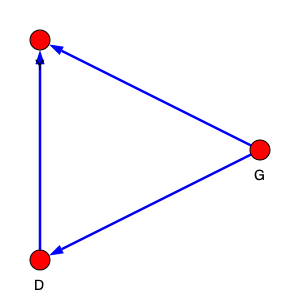

,nodes,edges,notació R
0,"G, D, Y","G->D, D->Y, G->Y","G-+D, D-+Y, G-+Y"


In [35]:
edges = ["G->D", "D->Y", "G->Y"]
DAG1, DAG1_summary = mostrar_graf(
    edges,
    "berkeley_dag_1",
)
display(DAG1_summary)

Tornem a insistir en què la pregunta “hi ha discriminació?” és terriblement ampla i no té una única traducció des del punt de vista de l'estadística. Ho veiem palès amb la quantitat de grafs que podem crear. 

Al seu torn, podem referir-nos, per exemple, a desigualtats agregades, a discriminació directa dins dels departaments, etc. El departament, per tant, pot actuar com a mediador, estrat, unitat de decisió, indicador de criteris d'admissió diferents...

## 10. Identificació causal i `causaleffect`

Amb `causaleffect` podem formular consultes (_queries_) causals sobre $G$, $D$ i $Y$ i veure quin estimand observacional ens retorna l'algorisme ID. L'algorisme, que hem estudiat en detall a la Memòria, intenta retornar sempre que sigui possible una expressió només via termes observables. Aquest algorisme és complet per a efectes causals en CBNs semi-Markovianes recursives en el sentit desenvolupat per [Shpitser i Pearl (2006)](#shpitser2006joint) i [Shpitser i Pearl (2008)](#shpitser2008). Ho expliquem en detall a la Memòria i aquí aprofitarem la implementació que ens dona el paquet `causaleffect`.

Aquí cal separar dues coses. En el graf que hem proposat, òbviament $G$ no té pares; per tant, observar $G=g$ i intervenir formalment sobre $G=g$ seran equivalents i donaran la mateixa expressió observacional.

Farem tres consultes, cadascuna amb una lectura diferent:

1. $P(Y\mid\operatorname{do}(G=g))$: què passa si intervenim formalment gèneres, sense fixar-nos en el departament?
2. $P(Y\mid\operatorname{do}(G=g),D=d)$: què veiem dins d'un departament observat (intervenint igualment el gènere)?
3. $P(Y\mid\operatorname{do}(G=g),\operatorname{do}(D=d))$: què passaria si, dins del model, intervinguéssim també el departament?

Aquesta tercera consulta ens servirà sobretot per marcar la diferència entre **condicionar** pel departament observat i **intervenir-lo** dins del model.

In [36]:
def probability_latex(probability, *, simplify: bool = True) -> str:
    """Retorna la fórmula LaTeX d'un objecte Probability sense modificar-lo.

    Quan activem `simplify=True` també simplifica Probability internament. Per
    això treballem sempre sobre una còpia, per poder mostrar l'expandida i la simplificada.

    Parameters
    ----------
    probability:
        Objecte retornat per `causaleffect.ID`.
    simplify:
        Si és `False`, veiem l'expressió tal com surt de l'algorisme abans de les
        simplificacions de presentació. Si és `True`, veiem la forma reduïda.
    """
    return probability.copy().printLatex(simplify=simplify)


def mostrar_estimand(title: str, probability) -> None:
    """Mostra la forma expandida i la simplificada d'un estimand.
    """
    expanded = probability_latex(probability, simplify=False)
    simplified = probability_latex(probability)

    display(
        Markdown(
            f"**{title}**\n\n"
            "$$\n"
            "\\begin{aligned}\n"
            f"\\text{{forma expandida:}} \\quad & \\displaystyle {expanded} \\\\\n"
            f"\\text{{forma simplificada:}} \\quad & \\displaystyle {simplified}\n"
            "\\end{aligned}\n"
            "$$"
        )
    )

Com ja hem dit, $G$ no té pares causals en aquesta CBN; per això, observar $G=g$ i intervenir sobre $G=g$ acaben coincidint. Sense simplificar, però, apareix explícitament el pas pel departament:

$$
P(Y \mid do(G=g)) = \sum_d P(Y \mid G=g, D=d)P(D=d \mid G=g).
$$

Amb el `simplify=True` podem aplicar probabilitats totals i aquesta mateixa quantitat queda com:

$$
P(Y \mid do(G=g)) = P(Y \mid G=g).
$$

En aquesta CBN Markoviana, l'estimand recull una comparació total: combina el camí $G\to D\to Y$ (homes i dones no apliquen als mateixos departaments) i el camí $G\to Y$ (possible influència directa del gènere en el procés d'admissió). Per tant, comparar $P(Y\mid G=\text{Male})$ i $P(Y\mid G=\text{Female})$ com hem fet al principi no mesura discriminació directa per si sol: també incorpora el paper mediador del departament.

Si, en canvi, demanem la consulta condicionada per $D$, tenim $P(Y\mid \operatorname{do}(G=g),D=d)$. Obtenim:

$$
P(Y \mid do(G=g),D=d) = P(Y \mid G=g,D=d).
$$

Aquesta condicionada és útil per mirar què passa dins d'un departament observat. Però ja no és la mateixa pregunta: deixa fora la part del camí que passa per la tria de departament. Tampoc convé anomenar-la _efecte directe_, ja que aquí hem condicionat pel departament observat i no l'hem fixat amb una intervenció.

Per això hem calculat també $P(Y\mid \operatorname{do}(G=g),\operatorname{do}(D=d))$. Amb aquesta pregunta volem saber el que passaria si també intervinguéssim sobre el departament. En la nostra CBN Markoviana, l'algorisme el redueix directament a $P(Y\mid G=g,D=d)$. Ara bé, això no implica que les dades ens donin la raó automàticament: de moment estem considerant un model de joguina, on no hem introduït cap variable oculta. O, dit d'una altra manera: **sí ens donen la raó, però en un model profundament irreal**.

El pas següent serà precisament preguntar-nos què passa si hi ha informació no observada que afecta alhora la tria del departament i l'admissió.

## 11. Model alternatiu amb variable latent

Com ja hem comentat, la secció anterior ha funcionat perquè hem assumit un model sense molta complicació, com si $G$, $D$ i $Y$ fossin les úniques variables rellevants. Però aquesta és una hipòtesi (molt còmoda, per cert) que no acostuma a ser certa a la vida real. Com en la majoria de casos aplicats, podria haver-hi una o diverses variables no observades. Per exemple:

$$
U = \text{perfil acadèmic, expedient, preparació, preferències, biaixos de l'entrevistador o altra informació no registrada.}
$$

El DAG induït pel model amb $U$ explícita, doncs, és:

$$
U \to D, \quad U \to Y, \quad G \to D, \quad D \to Y, \quad G \to Y.
$$

Aquí $U$ afecta tant la tria de departament com la probabilitat d'admissió. Així doncs, pot ser que part de la gent apliqui a certs departaments perquè té un perfil concret, i que aquest mateix perfil també influeixi en la probabilitat d'entrar. 

Bickel, Hammel i O'Connell ja adverteixen que variables com qualificació, promesa acadèmica o criteris legítims d'avaluació serien rellevants per interpretar causalment una diferència de taxes, però no estan disponibles les taules que utilitzem. **Les dades per si soles, doncs, no permeten demostrar la falta absoluta de discriminació ni tampoc estimar tots els efectes causals**.


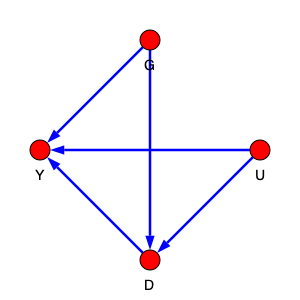

,nodes,edges,notació R
0,"U, D, Y, G","U->D, U->Y, G->D, D->Y, G->Y","U-+D, U-+Y, G-+D, D-+Y, G-+Y"


In [37]:
# Primer dibuixem U explícitament per deixar clara la hipòtesi substantiva:
# hi pot haver informació no observada que afecti alhora D i Y.
edges = ["U->D", "U->Y", "G->D", "D->Y", "G->Y"]
DAG2, DAG2_summary = mostrar_graf(
    edges,
    "berkeley_dag_2",
)
display(DAG2_summary)

Ara bé, representar-ho així no és correcte amb `causaleffect`, ja que interpretarà que $U$ és una variable exògena. Si ocultem $U$ i treballem només amb les variables observades, la seva presència es pot representar mitjançant una aresta bidirigida entre $D$ i $Y$:

$$
G \to D \to Y, \qquad G \to Y, \qquad D \leftrightarrow Y.
$$

Aquesta és la projecció latent que connecta el cas pràctic amb les CBNs semi-Markovianes i les components de confusió discutides a la memòria ([Pearl, 2009](#pearl2009causality); [Shpitser i Pearl, 2006](#shpitser2006joint)). Ja no és estrictament un DAG sobre les variables observades, sinó un ADMG. A la memòria hem convingut que aquestes arestes bidirigides codifiquen factors no observats compartits, en aquest cas entre departament i l'admissió. És exactament el punt delicat: si alguna variable no observada afecta tant $D$ com $Y$, llavors condicionar per $D$ i intervenir sobre $D$ ja no són intercanviables.


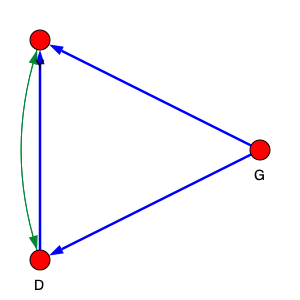

,nodes,edges,notació R
0,"G, D, Y","G->D, D->Y, G->Y, D<->Y","G-+D, D-+Y, G-+Y, D-+Y, D+-Y"


In [38]:
# Projectem U fora del graf observat. La confusió latent D<->Y queda
# representada com una aresta bidirigida entre les dues variables observades.
edges = ["G->D", "D->Y", "G->Y", "D<->Y"]
DAG3, DAG3_summary = mostrar_graf(
    edges,
    "berkeley_dag_3",
)
display(DAG3_summary)


In [39]:
# Consulta total sobre G: quin estimand identifica la CBN semi-Markoviana per P(Y | do(G))?
P = ID({"Y"}, {"G"}, DAG3)
# Consulta condicionada per departament, P(Y | do(G), D).
Pgd = ID({"Y"}, {"G"}, DAG3, cond={"D"})

mostrar_estimand("Consulta total sobre $G$", P)
mostrar_estimand("Consulta condicionada per $D$ fixant $G$", Pgd)

**Consulta total sobre $G$**

$$
\begin{aligned}
\text{forma expandida:} \quad & \displaystyle \sum_{d}P(d|g)P(y|d, g) \\
\text{forma simplificada:} \quad & \displaystyle P(y|g)
\end{aligned}
$$

**Consulta condicionada per $D$ fixant $G$**

$$
\begin{aligned}
\text{forma expandida:} \quad & \displaystyle \frac{P(d|g)P(y|d, g)}{\sum_{y}P(d|g)P(y|d, g)} \\
\text{forma simplificada:} \quad & \displaystyle \frac{P(d, y|g)}{P(d|g)}
\end{aligned}
$$

### Comparativa

La consulta sobre $G$ continua sent identificable amb les variables observades: en forma expandida torna a aparèixer la suma sobre departaments, i en forma simplificada queda $P(Y\mid G=g)$. Això està bé, però també és un pèl trivial: la confusió latent que hem dibuixat no entra com a causa comuna de $G$ i $Y$, sinó com a causa comuna de $D$ i $Y$. Per tant, si volem veure on incideix de veritat aquesta hipòtesi, hem de canviar les preguntes. És a dir, mirar preguntes on $D$ sigui alguna cosa més que una variable que observem.

| Consulta | Significat | CBN Markoviana (`DAG1`) | CBN semi-Markoviana (`DAG3`) |
|---|---|---|---|
| $P(Y\mid\operatorname{do}(G=g))$ | Fixem gèneres sense importar la distribució de departaments. | $P(Y\mid G=g)$. | Identificable: $P(Y\mid G=g)$ |
| $P(Y\mid\operatorname{do}(G=g),D=d)$ | Fixat el gènere, mirem què passa dins d'un departament observat (i.e. encara no hem fixat el departament). | $P(Y\mid G=g,D=d)$. | Identificable: $\dfrac{P(Y,D=d\mid G=g)}{P(D=d\mid G=g)}=P(Y\mid G=g,D=d)$ |
| $P(Y\mid\operatorname{do}(G=g),\operatorname{do}(D=d))$ | Quin tracte rebria una sol·licitud si, dins del model, fixéssim també el departament? | $P(Y\mid G=g,D=d)$. | No identificable pel _bow_ $D\to Y$ i $D\leftrightarrow Y$. |
| $P(Y\mid\operatorname{do}(D=d))$ | Intervenint el departament i res més, quina possibilitat tindríem de ser acceptats? | $\sum_g P(g)P(Y\mid D=d,G=g)$. | No identificable pel _bow_ $D\to Y$ i $D\leftrightarrow Y$. |

La darrera pregunta és temptadora perquè sona molt natural: si el departament és tan important, què passaria si l'intervinguéssim? Però aquí és on cal vigilar; és la mateixa idea que hem anat remarcant al llarg d'aquesta part pràctica. Si $U$ afecta alhora $D$ i $Y$, observar que algú és al departament $D=d$ també ens dona informació indirecta sobre $U$. En canvi, intervenir amb $\operatorname{do}(D=d)$ talla el mecanisme que ha portat aquella persona cap a aquell departament. No és el mateix món en el sentit que estem en esglaons diferents de la jerarquia causal de Pearl.

El subgraf format per $D$ i $Y$ ja conté el problema en miniatura: tenim $D\to Y$ i també $D\leftrightarrow Y$. Aquesta parella representa la situació clàssica en què volem estimar l'efecte d'una variable sobre una altra, però hi ha una causa comuna no observada entre totes dues. Idèntic al cas que exposem del tabac i el càncer a la memòria, abans de parlar del quitrà com a mediador. Aquest cas, molt habitual en inferència causal, s'anomena _bow_ i és un cas particular de _hedge_ ([Shpitser i Pearl, 2006](#shpitser2006joint); [Shpitser i Pearl, 2008](#shpitser2008)). Sortiran a la subsecció de _Problema_ més avall. Així doncs, el departament sembla causa del resultat, però també pot estar fent de pista sobre altres variables no mesurades.

Per això aquesta secció no diu simplement que algunes consultes siguin irresolubles per a la CBN semi-Markoviana `DAG3`. Diu una cosa més precisa: no tenim prou dades, les preguntes més fortes sobre fixar el departament ja no es poden respondre només amb dades observacionals d'aquest model concret. Qualsevol afirmació causal requereix dir quins nodes s'han observat, quins poden haver quedat latents i quin paper causal atribuïm al departament. Aquesta és, de fet, la gràcia de fer servir grafs, ja que ens obliguen a posar les cartes damunt la taula abans d'arribar a una conclusió precipitadament.


### Valors dels estimands

Tots els estimands de la taula anterior són per a $Y=1$, és a dir, admissió. La majoria dels valors corresponents a tals probabilitats es troben repartits al llarg d'aquesta part pràctica. Els recollirem tots en la taula inferior i, per a l'última fila de la CBN Markoviana, de la qual encara no hem fet els càlculs, farem servir l'ajustament per gènere:
$$
P(Y=1\mid\operatorname{do}(D=d))=\sum_g P(g)P(Y=1\mid D=d,G=g),
$$
amb $P(G=\text{Male})=\dfrac{2691}{4526}$ i $P(G=\text{Female})=\dfrac{1835}{4526}$.

In [40]:
weight_g = (
    df.groupby("Gender", observed=True)["Freq"]
    .sum()
    .div(df["Freq"].sum())
    .rename("P(G=g)")
)

taxes_dg = (
    df.pivot_table(
        index=["Dept", "Gender"],
        columns="Admit",
        values="Freq",
        aggfunc="sum",
        observed=True,
    )
    .reindex(columns=ADMIT_ORDER)
)

taxes_dg["Total"] = taxes_dg.sum(axis=1)
taxes_dg["P(Y=1 | D=d,G=g)"] = (
    taxes_dg["Admitted"] / taxes_dg["Total"]
)

do_d = (
    taxes_dg[["P(Y=1 | D=d,G=g)"]]
    .reset_index()
    .merge(weight_g.reset_index(), on="Gender")
)
do_d["contribucio"] = (
    do_d["P(G=g)"] * do_d["P(Y=1 | D=d,G=g)"]
)

val_do = (
    do_d.groupby("Dept", observed=True)["contribucio"]
    .sum()
    .rename("P(Y=1 | do(D=d))")
    .to_frame()
)

display(do_d.round(4))
display(val_do.round(4))

,Dept,Gender,"P(Y=1 | D=d,G=g)",P(G=g),contribucio
0,A,Male,0.6206,0.5946,0.3690
1,A,Female,0.8241,0.4054,0.3341
2,B,Male,0.6304,0.5946,0.3748
3,B,Female,0.6800,0.4054,0.2757
4,C,Male,0.3692,0.5946,0.2195
5,C,Female,0.3406,0.4054,0.1381
6,D,Male,0.3309,0.5946,0.1968
7,D,Female,0.3493,0.4054,0.1416
8,E,Male,0.2775,0.5946,0.1650
9,E,Female,0.2392,0.4054,0.0970


,P(Y=1 | do(D=d))
Dept,
A,0.7031
B,0.6505
C,0.3576
D,0.3384
E,0.2620
F,0.0636


| Consulta | CBN Markoviana (`DAG1`) | CBN semi-Markoviana (`DAG3`) |
|---|---|---|
| $P(Y=1\mid\operatorname{do}(G=g))$ | home: $0.4452$<br>dona: $0.3035$ | home: $0.4452$<br>dona: $0.3035$ |
| $P(Y=1\mid\operatorname{do}(G=g),D=d)$ | A: home $0.6206$, dona $0.8241$<br>B: home $0.6304$, dona $0.6800$<br>C: home $0.3692$, dona $0.3406$<br>D: home $0.3309$, dona $0.3493$<br>E: home $0.2775$, dona $0.2392$<br>F: home $0.0590$, dona $0.0704$ | A: home $0.6206$, dona $0.8241$<br>B: home $0.6304$, dona $0.6800$<br>C: home $0.3692$, dona $0.3406$<br>D: home $0.3309$, dona $0.3493$<br>E: home $0.2775$, dona $0.2392$<br>F: home $0.0590$, dona $0.0704$ |
| $P(Y=1\mid\operatorname{do}(G=g),\operatorname{do}(D=d))$ | A: home $0.6206$, dona $0.8241$<br>B: home $0.6304$, dona $0.6800$<br>C: home $0.3692$, dona $0.3406$<br>D: home $0.3309$, dona $0.3493$<br>E: home $0.2775$, dona $0.2392$<br>F: home $0.0590$, dona $0.0704$ | no-identificable |
| $P(Y=1\mid\operatorname{do}(D=d))$ | A: $0.7031$<br>B: $0.6505$<br>C: $0.3576$<br>D: $0.3384$<br>E: $0.2620$<br>F: $0.0636$ | no-identificable |

### No identificabilitat

Si intentem executar el següent codi:

```python
# Ara fixem formalment tant G com D.
Pgd = ID({"Y"}, {"G", "D"}, DAG3)

# Per últim, fixem sol D.
Pd = ID({"Y"}, {"D"}, DAG3)
```

Ens trobaríem amb l'error `Edge counts should be non-negative, found -1`. Aquest missatge ve d'`igraph` i no és el que esperaríem de l'algorisme ID; és a dir, que `causaleffect` s'entrebanca abans d'arribar al que hauríem, que és el cas de fallada de l'algorisme ID per _hedges_ ([Shpitser i Pearl, 2006](#shpitser2006joint); [Shpitser i Pearl, 2008](#shpitser2008)). Aquest cas apareix quan, en una crida recursiva, $C(\mathcal{G}[\mathcal{V}\setminus\mathbf{X}])$ té una sola C-component i també $C(\mathcal{G})=\{\mathcal{G}\}$; llavors l'algorisme retorna $\operatorname{FAIL}(\mathcal{G},\mathcal{G}[\mathbf{S}])$, cosa que implica l'existència d'un _hedge_. En el nostre cas, la crida problemàtica viu en el subgraf reduït

$$
\mathcal{H}=\mathcal{G}[\{D,Y\}],\quad D\to Y,\quad D\leftrightarrow Y.
$$

Per a la consulta $P(Y\mid\operatorname{do}(D=d))$ dins d'aquest subgraf, tenim $\mathbf{X}=\{D\}$, $\mathbf{Y}=\{Y\}$ i $\mathcal{V}_{\mathcal{H}}=\{D,Y\}$. Per tant,

$$
C\bigl(\mathcal{H}[\mathcal{V}_{\mathcal{H}}\setminus\mathbf{X}]\bigr)
= C(\mathcal{H}[\{Y\}])
=\{\mathcal{H}[\{Y\}]\},
$$

mentre que $C(\mathcal{H})=\{\mathcal{H}\}$, ja que $D$ i $Y$ estan connectats per l'aresta bidirigida. Així doncs, ID hauria de retornar $\operatorname{FAIL}\bigl(\mathcal{H},\mathcal{H}[\{Y\}]\bigr)$. El _hedge_ corresponent és la parella de C-boscos:

$$
\mathcal{F}=\bigl(\{D,Y\},\{D\to Y,\;D\leftrightarrow Y\}\bigr),
\qquad
\mathcal{F}'=\bigl(\{Y\},\varnothing\bigr).
$$

El primer C-bosc és el _bow_ format per $D$ i $Y$ que comentàvem; el segon, que és el subgraf trivial format només per $Y$, no la conté; i tots dos són C-boscos arrelats en $Y$ ($Y$-_rooted C-forests_). Notem, doncs, que hi ha alhora un efecte directe $D\to Y$ i una causa comuna latent en $D\leftrightarrow Y$. 

Si només tinguéssim $D\to Y$, l'efecte seria identificable; si només tinguéssim $D\leftrightarrow Y$ i no $D\to Y$, la consulta seria una altra. El problema és la combinació de les dues.

Convé separar els dos casos per veure que el `FAIL` és essencialment el mateix, però apareix en llocs lleugerament diferents de la recursió. 

1. Per a $P(Y\mid\operatorname{do}(G=g),\operatorname{do}(D=d))$, la crida inicial té $\mathbf{X}=\{G,D\}$ i $\mathbf{Y}=\{Y\}$. L'algorisme acaba reduint el problema a la C-component maximal $\{D,Y\}$, i allà la intervenció rellevant que queda és $D$. Per tant, el `FAIL` és:

$$
\operatorname{FAIL}\bigl(\mathcal{H},\mathcal{H}[\{Y\}]\bigr),
\qquad
\mathcal{H}=\mathcal{G}[\{D,Y\}].
$$

2. Per a $P(Y\mid\operatorname{do}(D=d))$, la crida inicial amb $\mathbf{X}=\{D\}$ primer separa el subgraf $\mathcal{G}[\{G,Y\}]$ en les C-components trivials $\{G\}$ i $\{Y\}$. El factor corresponent a $\{Y\}$ és precisament una consulta del tipus $\operatorname{ID}(\{Y\},\{G,D\},P,\mathcal{G})$, pel que es torna a caure en el mateix subproblema $\mathcal{H}=\mathcal{G}[\{D,Y\}]$. Així doncs, és el mateix `FAIL`: $\operatorname{FAIL}(\mathcal{H},\mathcal{H}[\{Y\}])$.

Així doncs, per resumir, ambdues haurien d'arribar a un cas de `FAIL`: `causaleffect` (tot i fer una implementació fantàstica de l'algorisme `ID`) s'entrebanca abans perquè representa l'aresta bidirigida $D\leftrightarrow Y$ mitjançant dues arestes $D\to Y$ i $Y\to D$. En presència del _bow_ $D\to Y$ i $D\leftrightarrow Y$, la mutilació $\operatorname{do}(D=d)$ deixa dues arestes $D\to Y$ i cap aresta $Y\to D$; això dona problemes quan intenta reconstruir les parts dirigida i bidirigida, ja que ho fa a partir d'una matriu d'adjacència que ha quedat malformada.

### Problema

El problema concret és la línia de la implementació de `ID_rec` on es construeix el graf mutilat $\mathcal{G}_{\overline{\mathbf{X}}}$, que opera estrictament a nivell de la projecció latent, és a dir, a l'ADMG de la CBN semi-Markoviana que ens ocupi. En la última versió de `causaleffect`, la línia és aquesta:

```python
G_x.delete_edges(G_x.es.select(_target_in=G_x.vs.select(name_in=X)))
```

La intenció és bona perquè ens trobem davant d'una intervenció $\operatorname{do}(\mathbf{X}=\mathbf{x})$ ($\mathbf{X}=D$ i $\mathbf{x}=d$) i hem d'eliminar arestes. Ara bé, en un ADMG, una aresta bidirigida vol dir una aresta entrant a cadascun dels dos extrems des d'un confusor. Per tant, si intervenim $D$, l'aresta $D\leftrightarrow Y$ s'ha d'eliminar sencera, no n'hi ha prou amb eliminar només la que apunta cap a $D$. **No estem negant l'existència de l'aresta $U\to Y$** (fer-ho seria completament incorrecte i, de fet, el _patch_ que es proposi ha de tenir-ho en compte), però en les projeccions latents de CBNs la convenció és no posar-la. Això és perquè després de fer la intervenció, $U$ serà causa d'una única variable endògena $Y$.

Aquesta distinció és important perquè `causaleffect` representa internament $D\leftrightarrow Y$ com dues arestes dirigides auxiliars, una en cada sentit, marcades amb l'atribut `confounding`. En el nostre graf, a més, també hi ha una aresta $D\to Y$. Quan el codi elimina només les arestes amb destí a $D$, desapareix $Y\to D$, però queda $D\to Y$ de l'aresta bidirigida. Així, després de la mutilació $\mathcal{G}_{\overline{D}}$, queden dues arestes $D\to Y$, una d'elles amb `confounding = -1`. A partir d'aquí, el codi intenta reconstruir les parts dirigida i bidirigida mitjançant matrius d'adjacència:

```python
adj_bidir = np.asarray(g.get_adjacency().data) + np.asarray(g.get_adjacency().data).T
adj_bidir[adj_bidir < 2] = 0
adj_bidir[adj_bidir >= 2] = 1
adj_dir = np.asarray(g.get_adjacency().data) - adj_bidir
g_dir = Graph.Adjacency(adj_dir.tolist())
```

En el nostre cas, la matriu d'adjacència mutilada té un `2` en la posició $D\to Y$, perquè hi ha dues arestes en la mateixa direcció. El codi interpreta això com si hi hagués una bidirigida entre $D$ i $Y$ i resta una matriu simètrica. El resultat és que apareix un valor negatiu en la posició $Y\to D$ i `igraph` rebutja amb el missatge `Edge counts should be non-negative, found -1`. 

En resum, el problema és que `causaleffect` ha deixat una aresta bidirigida a mig eliminar i després intenta trobar la part bidirigida només a partir de la matriu d'adjacència. El patch mínim és corregir la construcció de $\mathcal{G}_{\overline{\mathbf X}}$ ($\mathbf{X}=D$ i $\mathbf{x}=d$): cal eliminar les arestes dirigides entrants a $\mathbf X$ i, en la representació ADMG del paquet, també eliminar completament les bidirigides incidents a $\mathbf X$. La qual cosa, realment, és incorrecta: en aquest sentit, `get_directed_bidirected_graphs` és fràgil perquè reconstrueix la part bidirigida a partir sol de la matriu d’adjacència. Una versió més robusta hauria de refer la funció i s'hauria de basar més en l'atribut `confounding`.

## 12. Contrafactuals

El que afegim aquí és sobretot un canvi de notació. Algunes distribucions intervingudes que ja hem calculat amb `ID`/`IDC` admeten una lectura contrafactual poblacional: $Y_x$ denota el valor que tindria $Y$ sota la intervenció $x$.

Ara bé, això no converteix `causaleffect` en un paquet de contrafactuals generals. El paquet implementa `ID` i, quan passem `cond=...`, activa internament `IDC`; per a l'algorisme IDC, vegeu [Shpitser i Pearl (2012a)](#shpitser2012idc). No implementa ID*/IDC*. Per tant, no intentarem resoldre consultes del tipus $P(Y_{g,d}\mid G=g',D=d',Y=0)$, que sí que requereixen la maquinària pròpia dels contrafactuals complets ([Shpitser i Pearl, 2012b](#shpitser2012counterfactuals)).


### Dels `do` als contrafactuals

La relació amb les consultes de la secció anterior és aquesta:

| Quantitat contrafactual | Consulta ID/IDC corresponent | Algorisme |
|---|---|---|
| $P(Y_g)$ | $P(Y\mid\operatorname{do}(G=g))$ | `ID` |
| $P(Y_g\mid D_g=d)$ | $P(Y\mid\operatorname{do}(G=g),D=d)$ | `IDC` |
| $P(Y_{g,d})$ | $P(Y\mid\operatorname{do}(G=g),\operatorname{do}(D=d))$ | `ID` |
| $P(Y_d)$ | $P(Y\mid\operatorname{do}(D=d))$ | `ID` |
| $P(Y_{g,d}\mid G=g',D=d',Y=0)$ | fora de les consultes ID/IDC ordinàries | ID*/IDC* |


### Una mini-aplicació: canviar formalment de departament

Sota `DAG1`, podem fer una lectura contrafactual poblacional molt senzilla: per a un gènere $G=g$, què prediu el model si el departament fos intervingut a $D=d'$? En aquest model, que és clarament Markovià (no només no tenim confusors, sinó que directament no considerem variables exògenes):

$$
P(Y_{d'}=1\mid G=g)
\equiv P(Y=1\mid\operatorname{do}(D=d'),G=g)
= P(Y=1\mid D=d',G=g).
$$

La taula següent no estima el contrafactual d'una sol·licitud individual concreta; només reexpressa, sota `DAG1` (és a dir, en capa associativa $\mathcal{L}_1$), les taxes observades dins de cada parella departament-gènere com si fossin el resultat d'assignar formalment aquell departament.


In [41]:
what_if_department = (
    taxes_dg["P(Y=1 | D=d,G=g)"]
    .unstack("Gender")
    .reindex(index=DEPT_ORDER, columns=GENDER_ORDER)
)

what_if_department["Female - Male"] = (
    what_if_department["Female"] - what_if_department["Male"]
)

what_if_department_display = what_if_department.rename(
    columns={
        "Male": "P(Y_{d'}=1 | G=Male)",
        "Female": "P(Y_{d'}=1 | G=Female)",
        "Female - Male": "diferencia Female - Male",
    }
)

display(what_if_department_display.round(4))


Gender,P(Y_{d'}=1 | G=Male),P(Y_{d'}=1 | G=Female),diferencia Female - Male
Dept,,,
A,0.6206,0.8241,0.2035
B,0.6304,0.6800,0.0496
C,0.3692,0.3406,-0.0286
D,0.3309,0.3493,0.0184
E,0.2775,0.2392,-0.0383
F,0.0590,0.0704,0.0114


La lectura és útil com a exercici: en `DAG1`, el departament $A$ seria el més favorable per a tots dos grups i el departament $F$ el menys favorable. Però, com abans, les conclusions que en traiem són força irrellevants, ja que el model és de joguina. La taula no aguanta bé el canvi de model: si acceptem `DAG3` no podem garantir una conclusió similar, ja que no podem inferir-la només amb les dades observades.

## 13. Conclusions

El recorregut del notebook ha estat deliberadament de menys a més. Hem començat amb una taula de contingència aparentment senzilla i hem acabat de ple en l'algorisme ID. 

En la taula marginal, la diferència és clara: agregadament, la taxa d'admissió masculina és superior a la femenina. Ara bé, aquesta primera és només una lectura a nivell associatiu. Quan posem la taula per departaments, veiem que el gènere no es distribueix igual, i cal tenir en compte que els departaments tampoc tenen la mateixa selectivitat. Per tant, el departament és una variable estructural que canvia completament la pregunta que estem responent.

Aquesta és la part on el cas connecta amb la paradoxa de Simpson. En `UCBAdmissions` no tenim una reversió perfecta en tots els estrats, de manera que no podem vendre'l com un Simpson pur. Però sí que tenim el fenomen característic d'aquesta paradoxa: condicionar per una variable rellevant pot canviar la direcció d'una associació. Les mesures d'associació que hem fet, l'anàlisi estratificada, el test de Cochran--Mantel--Haenszel... tots apunten cap al mateix: abans d'arribar a una conclusió (precipitadament) amb la diferència marginal, cal saber quines variables són rellevants per a fer-ho.

També hem vist que ajustar, estratificar o estandarditzar aporta matisos rellevants. Quan usem pesos marginals comuns per comparar departaments, estem canviant explícitament la població de referència. Això pot ser útil, però no és neutral, ja que respon una pregunta completament diferent a la pregunta original. Dit d'una altra manera, hi ha un munt d'estimands, i cada un depèn de quina pregunta volem respondre o quina comparació volem resoldre.

El fet de representar consultes causals amb grafs, gràcies al model establert per [Pearl (2009)](#pearl2009causality), és una manera molt intuïtiva i completa de treballar aquestes preguntes. En la primera CBN Markoviana (`DAG1`), on només considerem $G$, $D$ i $Y$ sense confusió latent, `causaleffect` identifica les consultes esperades: $P(Y\mid\operatorname{do}(G=g))$, $P(Y\mid\operatorname{do}(G=g),D=d)$ i $P(Y\mid\operatorname{do}(G=g),\operatorname{do}(D=d))$ es poden reescriure en termes observacionals. Condicionar i intervenir generalment no signifiquen el mateix, però en aquestes consultes això passa. L'estudi es complica quan introduïm _confusors latents_.

El model alternatiu amb una variable latent és més real, però també més complicat. Si acceptem que pot haver-hi un factor no observat $U$ que afecta alhora la tria de departament i l'admissió, la projecció observada conté el _bow_ $D\to Y$ i $D\leftrightarrow Y$. Llavors observar $D=d$ i intervenir $\operatorname{do}(D=d)$ ja no són intercanviables i les consultes ja no són totes identificables. Observar un departament ens dona informació indirecta sobre les variables no observades que han portat aquella persona fins allà, i intervenir el departament talla justament aquest mecanisme. Aquest és el salt conceptual que la taula, tota sola, no pot fer.

Per això les consultes amb $\operatorname{do}(D)$ deixen de ser identificables en la CBN semi-Markoviana `DAG3`. El subproblema rellevant és $\mathcal{H}=\mathcal{G}[\{D,Y\}]$, amb $D\to Y$ i $D\leftrightarrow Y$, i l'algorisme ID hauria d'arribar al `FAIL` associat al _hedge_ format per $\mathcal{F}=(\{D,Y\},\{D\to Y,D\leftrightarrow Y\})$ i $\mathcal{F}'=(\{Y\},\varnothing)$ ([Shpitser i Pearl, 2006](#shpitser2006joint); [Shpitser i Pearl, 2008](#shpitser2008)). El fet que la implementació Python de `causaleffect` s'entrebanqui abans per la qüestió del _bow_ és un detall interessant, però no canvia la conclusió final: amb aquest graf i aquestes variables observades, no hi ha estimand observacional possible per a aquestes consultes.

Així doncs, el cas Berkeley no permet concloure automàticament que hi hagués discriminació a les dones per accedir a una plaça de postgrau, però tampoc permet concloure que no n'hi hagués cap. El que sí que permet és veure per què aquestes afirmacions són massa fortes si no diem abans quin model causal assumim (quines variables decidim incloure o no). La lectura més conservadora és la de [Bickel, Hammel i O'Connell (1975)](#bickel1975sex): la diferència agregada és compatible amb una "diferència de composició entre departaments de selectivitat desigual. Però, un cop introduïm la possibilitat de variables no observades, la pregunta sobre què passaria si fixéssim formalment el departament ja no es pot respondre només amb `UCBAdmissions`.

En definitiva, la paradoxa de Simpson va molt més enllà de taules de contingència $2\times 2$ ([Simpson, 1951](#simpson1951); [Good i Mittal, 1987](#good1987); [Samuels, 1993](#samuels1993)). Posa de manifest la fragilitat de les interpretacions causals quan canviem de nivell d'anàlisi. La conclusió no és que les dades no diguin res; és que diuen coses diferents segons la pregunta que els fem. I, en causalitat, formular la pregunta correcta (potser com a la vida mateixa) ja és mitja feina.

## Bibliografia

Aquesta selecció recull les fonts citades al notebook. El catàleg compartit del treball es manté a `res/bibl.bib`.

### Fonts acadèmiques

<a id="bickel1975sex"></a>
- **Bickel, P. J., Hammel, E. A. i O'Connell, J. W. (1975).** “Sex Bias in Graduate Admissions: Data from Berkeley”. _Science_, 187(4175), 398–404. [DOI](https://doi.org/10.1126/science.187.4175.398)

<a id="breslow1980"></a>
- **Breslow, N. E. i Day, N. E. (1980).** _Statistical Methods in Cancer Research. Volume I: The Analysis of Case-Control Studies_. IARC Scientific Publications, 32. [IARC](https://publications.iarc.who.int/Book-And-Report-Series/Iarc-Scientific-Publications/Statistical-Methods-In-Cancer-Research-Volume-I-The-Analysis-Of-Case-Control-Studies-1980)

<a id="good1987"></a>
- **Good, I. J. i Mittal, Y. (1987).** “The Amalgamation and Geometry of Two-by-Two Contingency Tables”. _The Annals of Statistics_, 15(2), 694–711. [DOI](https://doi.org/10.1214/aos/1176350369)

<a id="mantel1959"></a>
- **Mantel, N. i Haenszel, W. (1959).** “Statistical Aspects of the Analysis of Data from Retrospective Studies of Disease”. _Journal of the National Cancer Institute_, 22(4), 719–748. [Article](https://academic.oup.com/jnci/article-abstract/22/4/719/900746)

<a id="pearl2009causality"></a>
- **Pearl, J. (2009).** _Causality: Models, Reasoning, and Inference_ (2a ed.). Cambridge University Press. [Editorial](https://www.cambridge.org/core/books/causality/B0046844FAE10CBF274D4ACBDAEB5F5B)

<a id="samuels1993"></a>
- **Samuels, M. L. (1993).** “Simpson's Paradox and Related Phenomena”. _Journal of the American Statistical Association_, 88(421), 81–88. [DOI](https://doi.org/10.1080/01621459.1993.10594297)

<a id="shpitser2006joint"></a>
- **Shpitser, I. i Pearl, J. (2006).** “Identification of Joint Interventional Distributions in Recursive Semi-Markovian Causal Models”. _Proceedings of AAAI-06_, 1219–1226. [AAAI](https://cdn.aaai.org/AAAI/2006/AAAI06-191.pdf)

<a id="shpitser2008"></a>
- **Shpitser, I. i Pearl, J. (2008).** “Complete Identification Methods for the Causal Hierarchy”. _Journal of Machine Learning Research_, 9, 1941–1979. [JMLR](https://jmlr.org/papers/v9/shpitser08a.html)

<a id="shpitser2012idc"></a>
- **Shpitser, I. i Pearl, J. (2012a).** “Identification of Conditional Interventional Distributions”. [arXiv:1206.6876](https://arxiv.org/abs/1206.6876)

<a id="shpitser2012counterfactuals"></a>
- **Shpitser, I. i Pearl, J. (2012b).** “What Counterfactuals Can Be Tested”. [arXiv:1206.5294](https://arxiv.org/abs/1206.5294)

<a id="simpson1951"></a>
- **Simpson, E. H. (1951).** “The Interpretation of Interaction in Contingency Tables”. _Journal of the Royal Statistical Society: Series B (Methodological)_, 13(2), 238–241. [DOI](https://doi.org/10.1111/j.2517-6161.1951.tb00088.x)

<a id="stigler1980eponymy"></a>
- **Stigler, S. M. (1980).** “Stigler's Law of Eponymy”. _Transactions of the New York Academy of Sciences_, 39(1 Series II), 147–157. [DOI](https://doi.org/10.1111/j.2164-0947.1980.tb02775.x)

<a id="vilar2024estadistica"></a>
- **Vilar, M. (2024).** _Apunts de classe: Estadística (EST)_. Grau en Matemàtiques, Universitat de Barcelona, curs 2023–2024.

### Documentació de dades i programari

<a id="ucbadmissions-doc"></a>
- **R Core Team.** [`UCBAdmissions`: Student Admissions at UC Berkeley](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/UCBAdmissions.html). Documentació oficial del paquet `datasets` de R.

<a id="statsmodels-get-rdataset"></a>
- **statsmodels.** [`statsmodels.datasets.get_rdataset`](https://www.statsmodels.org/stable/datasets/statsmodels.datasets.get_rdataset.html). Documentació oficial.

<a id="statsmodels-stratifiedtable"></a>
- **statsmodels.** [`statsmodels.stats.contingency_tables.StratifiedTable`](https://www.statsmodels.org/stable/generated/statsmodels.stats.contingency_tables.StratifiedTable.html). Documentació oficial.